# AES·SHA 최대 시간 해상도 비교

이 노트북은 하나의 STM32F303이 실행하는 AES-128과 SHA-256을 한 시간
윈도우에 넣고 다음 네 측정 조건의 시간축 해상도와 파형 유사성을 비교한다.

| 조건 | 시간축 정책 |
|---|---|
| ChipWhisperer-Lite | 타깃 클럭당 1 sample |
| ChipWhisperer-Husky | 타깃 클럭당 4 samples |
| PicoScope 3418E 8-bit | A/B 동시 사용 시 가능한 최고 sample rate |
| PicoScope 3418E 10-bit | 이 모델의 최대 bit depth에서 가능한 최고 sample rate |

PicoScope A는 Husky Measure와 같은 신호를 DC 50 Ω으로, B는 Husky USERIO
D0와 같은 트리거를 GPIO를 부하하지 않는 DC 1 MΩ으로 본다. 3418E API에는
ChipWhisperer식 dB gain이 없으므로 그에 대응하는 Y축 감도는 A input range·
analog offset·x1 probe scale로 최적화한다. Lite·Husky gain은 비교 기준인
25 dB로 고정한다. 한 실행의 첫 HIGH 펄스는 AES 키 확장과 암호화,
두 번째 HIGH 펄스는 SHA-256을 표시한다.

두 Pico 모드는 서로 다른 물리 실행이므로 같은 순간을 측정한 것은 아니다.
대신 고정 입력 5개와 seed로 결정되는 무작위 입력 100개를 두 모드에서
같은 순서로 실행한다. 각 모드 안에서는 Lite·Husky·Pico가 같은 물리
이벤트를 동시에 측정한다.

Run All은 의존성 준비, 펌웨어 빌드·플래시, 두 Pico 모드별 10개 수직축
탐색과 10개 검증, 총 210회의 3중 수집, 서로 다른 길이의 파형 전처리,
시각·통계 비교와 장비 해제를 모두
수행한다. 유사성 수치에는 임의의 합격선을 두지 않는다.

## 1. 실행 환경 준비

ChipWhisperer Docker 이미지에 없는 Pico Python wrapper와 native driver는
이 서브프로젝트의 .runtime 디렉터리에만 고정 버전으로 준비한다. 전역
Python 환경과 Docker 이미지는 바꾸지 않는다. 캐시가 없을 때만 네트워크를
사용하며 이후 Run All은 같은 파일을 재사용한다.

In [1]:
import importlib
import os
import shutil
import subprocess
import sys
import urllib.request
from pathlib import Path

PROJECT_DIR = Path('/workspace/[extra] PicoScope')
if not PROJECT_DIR.is_dir():
    raise RuntimeError(
        'chipwhisperer-kor Docker의 /workspace에서 실행해야 합니다.'
    )

RUNTIME_DIR = PROJECT_DIR / '.runtime'
LOCAL_PYTHON_DIR = RUNTIME_DIR / 'python'
PICO_DRIVER_ROOT = RUNTIME_DIR / 'picoscope'
PICO_DRIVER_LIB = PICO_DRIVER_ROOT / 'lib' / 'libpsospa.so'
DOWNLOAD_DIR = RUNTIME_DIR / 'downloads'
RUNTIME_DIR.mkdir(exist_ok=True)

PYPICOSDK_VERSION = '1.7.5'
PICO_DRIVER_PACKAGE = 'libpsospa_1.1.7-0r5994_amd64.deb'
PICO_DRIVER_URL = (
    'https://labs.picotech.com/picoscope7/debian/pool/main/libp/libpsospa/'
    + PICO_DRIVER_PACKAGE
)

if not (LOCAL_PYTHON_DIR / 'pypicosdk').is_dir():
    print(f'[준비] pypicosdk {PYPICOSDK_VERSION} 로컬 설치')
    subprocess.run(
        [
            sys.executable, '-m', 'pip', 'install', '--no-deps',
            '--no-cache-dir', '--target', str(LOCAL_PYTHON_DIR),
            f'pypicosdk=={PYPICOSDK_VERSION}',
        ],
        check=True,
    )

sys.path.insert(0, str(LOCAL_PYTHON_DIR))
importlib.invalidate_caches()

if not PICO_DRIVER_LIB.exists():
    print(f'[준비] {PICO_DRIVER_PACKAGE} 로컬 추출')
    DOWNLOAD_DIR.mkdir(exist_ok=True)
    package_path = DOWNLOAD_DIR / PICO_DRIVER_PACKAGE
    if not package_path.exists():
        request = urllib.request.Request(
            PICO_DRIVER_URL, headers={'User-Agent': 'curl/8.0'}
        )
        with urllib.request.urlopen(request) as response:
            with package_path.open('wb') as output:
                shutil.copyfileobj(response, output)

    extract_dir = RUNTIME_DIR / 'driver-extract'
    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    extract_dir.mkdir()
    subprocess.run(
        ['dpkg-deb', '-x', str(package_path), str(extract_dir)],
        check=True,
    )
    source_root = extract_dir / 'opt' / 'picoscope'
    if not (source_root / 'lib').is_dir():
        raise RuntimeError(
            f'Pico driver 패키지 구조를 확인할 수 없습니다: {source_root}'
        )
    if PICO_DRIVER_ROOT.exists():
        shutil.rmtree(PICO_DRIVER_ROOT)
    shutil.copytree(source_root, PICO_DRIVER_ROOT, symlinks=True)
    shutil.rmtree(extract_dir)

if not PICO_DRIVER_LIB.exists():
    raise RuntimeError(f'Pico driver 파일이 없습니다: {PICO_DRIVER_LIB}')

print('[✓] 노트북 전용 Pico 런타임 준비 완료')
print(f'    Python wrapper: {LOCAL_PYTHON_DIR}')
print(f'    Native driver: {PICO_DRIVER_LIB}')

[✓] 노트북 전용 Pico 런타임 준비 완료
    Python wrapper: /workspace/[extra] PicoScope/.runtime/python
    Native driver: /workspace/[extra] PicoScope/.runtime/picoscope/lib/libpsospa.so


## 2. 실험 설정과 공통 도구

다음 셀이 이 실험의 물리 설정과 횟수에 대한 단일 진실 공급원이다.
3418E는 실제 driver에서 12-bit 이상을 지원하지 않으므로 최대 비트 조건을
10-bit로 명시한다. 그러나 sample rate와 메모리 용량은 하드코딩하지 않고
Run All 때 A/B 채널이 활성화된 실제 장비에서 조회한다.

사전 측정은 공식 210회에 포함하지 않는다. 먼저 broad range로 두 연산의 끝
시각만 정한다. 이어서 공식 수집과 같은 최고 sample rate에서 8-bit와 10-bit
각각 10개 파형의 전체 min/max를 측정한다. 두 모드 전체를 포괄하는 하나의
A range·analog offset을 고른다. broad 8-bit 양자화가 지나치게 보수적인 range를
만들 수 있으므로 각 모드의 10개 검증 파형으로 더 작은 공통 range가 가능한 동안
반복한다. 최종 10개씩이 양쪽 ADC rail의 10% 이상을 비웠을 때만 공식 수집을 시작한다.

In [2]:
import gc
import hashlib
import random
import time
import warnings
from fractions import Fraction

import chipwhisperer as cw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from Crypto.Cipher import AES
from IPython.display import display
from scipy import signal

import pypicosdk as psdk

psdk.override_directory(str(PICO_DRIVER_ROOT))

PLATFORM = 'CW308_STM32F3'
CRYPTO_TARGET = 'NONE'
SS_VER = 'SS_VER_2_1'
HUSKY_SERIAL_NUMBER = '502032204c5846303130313137313032'
LITE_SERIAL_NUMBER = '44203120394d36433130322030313035'

FIRMWARE_DIR = PROJECT_DIR / 'simpleserial_main'
FIRMWARE_PATH = (
    FIRMWARE_DIR / f'simpleserial-scope-compare-{PLATFORM}.hex'
)
BUILD_OPTIONS = (
    f'PLATFORM={PLATFORM}',
    f'CRYPTO_TARGET={CRYPTO_TARGET}',
    f'SS_VER={SS_VER}',
)

AES_KEY_BYTES = 16
MESSAGE_BYTES = 64
RESULT_BYTES = 48
FIXED_CAPTURES = 5
RANDOM_CAPTURES = 100
RANDOM_SEED = 1

CW_GAIN_DB = 25
MAX_LITE_SAMPLES = 24_000
PRETRIGGER_PERCENT = 10
CAPTURE_POST_MARGIN_US = 50.0
ALIGNMENT_LIMIT_US = 2.0

PICO_MODES = (
    ('8-bit', '8bit'),
    ('10-bit (max-bit)', '10bit'),
)
PICO_TRIGGER_THRESHOLD_MV = 150
PICO_AUTO_TRIGGER_US = 1_000_000
PICO_SURVEY_RATE_SPS = 5_000_000
PICO_SURVEY_SAMPLES = 100_000
PICO_FASTEST_INTERVAL_REQUEST_S = 1e-12
PICO_ALIGNMENT_RATE_LIMIT_SPS = 100_000_000
PICO_VERTICAL_PREFLIGHTS = 10
# 10개 사전 입력에 없던 변화의 여유로 각 rail 10%를 비운다. 본 수집은
# 95%를 넘으면 동일 수직 설정 비교가 깨진 것으로 보고 즉시 중단한다.
PICO_VERTICAL_RAIL_LIMIT = 0.90
PICO_FORMAL_RAIL_LIMIT = 0.95
PICO_A_COUPLING = psdk.COUPLING.DC_50OHM
PICO_B_COUPLING = psdk.COUPLING.DC
PICO_B_RANGE = psdk.RANGE.V1
PICO_BANDWIDTH = psdk.BANDWIDTH_CH.BW_FULL
PICO_PROBE_SCALE = 1.0
PICO_A_RANGES = (
    (10, psdk.RANGE.mV10),
    (20, psdk.RANGE.mV20),
    (50, psdk.RANGE.mV50),
    (100, psdk.RANGE.mV100),
    (200, psdk.RANGE.mV200),
    (500, psdk.RANGE.mV500),
    (1_000, psdk.RANGE.V1),
    (2_000, psdk.RANGE.V2),
    (5_000, psdk.RANGE.V5),
)

SPECTRUM_SEGMENT_SAMPLES = 32_768
SPECTRUM_WINDOWS = 16
DISPLAY_ENVELOPE_POINTS = 4_000

FIXED_KEY = bytes(range(AES_KEY_BYTES))
FIXED_MESSAGE = bytes(range(MESSAGE_BYTES))

plt.rcParams['figure.dpi'] = 110
print('[✓] 실험 설정 로드 완료')
print(
    f'    Pico 모드당 고정 {FIXED_CAPTURES}회 + '
    f'무작위 {RANDOM_CAPTURES}회'
)
print(f'    공식 3중 수집 총 {(FIXED_CAPTURES + RANDOM_CAPTURES) * 2}회')

/usr/local/lib/python3.12/site-packages/chipwhisperer/capture/trace/TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


[✓] 실험 설정 로드 완료
    Pico 모드당 고정 5회 + 무작위 100회
    공식 3중 수집 총 210회


In [3]:
def my_fsr_cmd(target, cmd, scmd, data, payload_only=False):
    '''SimpleSerial 2.1 명령을 보내고 500 ms 안에 응답을 반환한다.

    송신 전에 남은 ACK를 버린다. 응답 없음은 TimeoutError, 손상된
    프레임은 ValueError를 발생시킨다. UART 버퍼와 타겟 상태를 바꾼다.
    '''
    target.flush()
    target.send_cmd(cmd=cmd, scmd=ord(scmd), data=data)
    response = target.read_cmd(timeout=500)
    if response is None:
        raise TimeoutError(f'SimpleSerial 응답 없음: 0x{cmd:02x}/{scmd}')
    if len(response) < 3:
        raise ValueError(f'응답 프레임이 너무 짧습니다: {response!r}')
    payload_end = 3 + response[2]
    if len(response) < payload_end:
        raise ValueError(f'응답 길이가 올바르지 않습니다: {response!r}')
    return bytes(response[3:payload_end]) if payload_only else response


def reset_target(scope, delay=0.05):
    '''Lite nRST로 타겟을 재시작하고 UART 준비 시간을 확보한다.'''
    scope.io.nrst = 'low'
    time.sleep(delay)
    scope.io.nrst = 'high_z'
    time.sleep(delay)


def golden_result(key, message):
    '''AES-128(message[:16]) || SHA-256(message || AES 결과)를 반환한다.'''
    ciphertext = AES.new(bytes(key), AES.MODE_ECB).encrypt(
        bytes(message[:16])
    )
    digest = hashlib.sha256(bytes(message) + ciphertext).digest()
    return ciphertext + digest


def run_target_transaction(target, key, message):
    '''입력을 저장하고 복합 연산을 실행해 검증된 결과를 반환한다.

    입력 길이, echo, 완료 응답 또는 호스트 골든 모델이 다르면 즉시
    실패한다. 타겟 입력·결과 상태와 trigger pin을 변경한다.
    '''
    if len(key) != AES_KEY_BYTES or len(message) != MESSAGE_BYTES:
        raise ValueError('키는 16바이트, 메시지는 64바이트여야 합니다.')
    if my_fsr_cmd(target, 0x81, 'k', key, True) != bytes(key):
        raise RuntimeError('타겟 AES 키 echo가 입력과 다릅니다.')
    if my_fsr_cmd(target, 0x81, 'm', message, True) != bytes(message):
        raise RuntimeError('타겟 SHA 메시지 echo가 입력과 다릅니다.')
    if my_fsr_cmd(target, 0x82, 'c', [], True) != b'\x01':
        raise RuntimeError('복합 연산 완료 응답이 올바르지 않습니다.')
    result = my_fsr_cmd(target, 0x83, 'r', [], True)
    expected = golden_result(key, message)
    if result != expected:
        raise RuntimeError(
            'AES·SHA 골든 모델 불일치\n'
            f'타겟: {result.hex()}\n골든: {expected.hex()}'
        )
    return result


def configure_pico_channels(pico, vertical):
    '''Pico A 측정과 B 상승 에지 trigger의 전체 front-end를 구성한다.

    A의 DC 50 Ω은 실제 회로 부하이므로 자동 fallback하지 않는다. B는 GPIO
    trigger를 부하하지 않도록 DC 1 MΩ로 고정한다. vertical은 A range와
    analog offset의 단일 정의이며 장비 상태를 변경한다.
    '''
    pico.set_channel(
        channel=psdk.CHANNEL.A,
        range=vertical['range_enum'],
        coupling=PICO_A_COUPLING,
        offset=vertical['offset_v'],
        bandwidth=PICO_BANDWIDTH,
        probe_scale=PICO_PROBE_SCALE,
    )
    pico.set_channel(
        channel=psdk.CHANNEL.B,
        range=PICO_B_RANGE,
        coupling=PICO_B_COUPLING,
        offset=0.0,
        bandwidth=PICO_BANDWIDTH,
        probe_scale=PICO_PROBE_SCALE,
    )
    pico.set_simple_trigger(
        channel=psdk.CHANNEL.B,
        threshold=PICO_TRIGGER_THRESHOLD_MV,
        threshold_unit='mv',
        direction=psdk.TRIGGER_DIR.RISING,
        auto_trigger=PICO_AUTO_TRIGGER_US,
    )


def open_pico(serial_number, resolution, vertical):
    '''지정 해상도로 3418E를 열고 A/B를 구성해 새 handle을 반환한다.'''
    pico = psdk.psospa()
    try:
        pico.open_unit(
            serial_number=serial_number, resolution=resolution
        )
        variant = pico.get_unit_info(psdk.UNIT_INFO.PICO_VARIANT_INFO)
        if variant != '3418E':
            raise RuntimeError(
                f'연결된 PicoScope가 3418E가 아닙니다: {variant}'
            )
        configure_pico_channels(pico, vertical)
        return pico
    except Exception:
        try:
            pico.close_unit()
        except Exception:
            pass
        raise


def close_pico(pico):
    '''열린 Pico block capture를 멈추고 USB handle을 해제한다.'''
    if pico is None:
        return
    try:
        pico.stop()
    except Exception:
        pass
    pico.close_unit()
    # pypicosdk 1.7.5의 destructor는 close 뒤에도 이전 handle 번호를
    # 다시 닫는다. 다음 resolution이 같은 번호를 재사용하면 새 연결이
    # 끊기므로 이미 닫은 객체의 handle을 명시적으로 무효화한다.
    pico.handle.value = 0


def detect_trigger_pulses(
    trigger_adc, threshold_adc, start_us, sample_rate_sps
):
    '''Pico B 원시 ADC에서 AES·SHA 두 HIGH 구간을 µs로 반환한다.

    길이 2 sample 미만 교차는 잡음으로 버린다. 정확히 두 펄스가
    아니면 구간 정본을 만들 수 없으므로 RuntimeError를 발생시킨다.
    입력 배열은 변경하지 않는다.
    '''
    high = np.asarray(trigger_adc) >= threshold_adc
    changes = np.flatnonzero(high[1:] != high[:-1]) + 1
    starts = changes[high[changes]]
    ends = changes[~high[changes]]
    if high[0]:
        starts = np.r_[0, starts]
    if high[-1]:
        ends = np.r_[ends, len(high)]
    pulses = [
        (int(start), int(end))
        for start, end in zip(starts, ends)
        if end - start >= 2
    ]
    if len(pulses) != 2:
        raise RuntimeError(
            'Pico B에서 유효한 trigger 펄스 2개가 필요하지만 '
            f'{len(pulses)}개를 검출했습니다.'
        )
    return tuple(
        (
            start_us + start / sample_rate_sps * 1e6,
            start_us + end / sample_rate_sps * 1e6,
        )
        for start, end in pulses
    )


def arm_pico(pico, timebase, samples, pretrigger_percent):
    '''A/B int16 버퍼를 만들고 비동기 block capture를 시작한다.'''
    buffers = pico.set_data_buffer_for_enabled_channels(samples)
    pico.run_block_capture(
        timebase, samples, pre_trig_percent=pretrigger_percent
    )
    return {
        'buffers': buffers,
        'timebase': int(timebase),
        'samples': int(samples),
        'pretrigger_percent': int(pretrigger_percent),
    }


def read_pico_raw(pico, armed, sample_rate_sps, retain_trigger=False):
    '''완료된 Pico A/B block을 읽어 A 원시 코드와 trigger 경계를 반환한다.

    A는 전체를 새 int16 배열로 복사한다. B는 경계를 검출한 뒤 기본적으로
    버리며 retain_trigger일 때만 사용자 시각화를 위해 복사한다.
    SDK buffer를 읽고 장비 over-range 상태를 갱신한다.
    '''
    actual_samples = pico.get_values(armed['samples'])
    if actual_samples != armed['samples']:
        raise RuntimeError(
            f'Pico sample 수 {actual_samples:,} != '
            f'{armed["samples"]:,}'
        )
    raw_a = np.asarray(
        armed['buffers'][psdk.CHANNEL.A][:actual_samples],
        dtype=np.int16,
    ).copy()
    raw_b = np.asarray(
        armed['buffers'][psdk.CHANNEL.B][:actual_samples],
        dtype=np.int16,
    )
    pre_samples = int(
        actual_samples * armed['pretrigger_percent'] / 100
    )
    start_us = -pre_samples / sample_rate_sps * 1e6
    threshold_adc = pico.mv_to_adc(
        PICO_TRIGGER_THRESHOLD_MV, psdk.CHANNEL.B
    )
    pulses_us = detect_trigger_pulses(
        raw_b, threshold_adc, start_us, sample_rate_sps
    )
    record = {
        'pico_a_raw': raw_a,
        'pulses_us': pulses_us,
        'over_range_mask': int(getattr(pico, 'over_range', 0)),
        'peak_adc_fraction': (
            float(
                np.max(np.abs(raw_a.astype(np.int32)))
            ) / float(pico.max_adc_value)
        ),
    }
    if retain_trigger:
        record['pico_b_raw'] = raw_b.copy()
    return record


def get_pico_offset_limits(pico):
    '''3418E JSON과 X1·DC 50 Ω에서 range별 offset 한계와 원본을 반환한다.

    반환값은 ({full_scale_mv: (minimum_v, maximum_v)}, details)다. 필요한
    모델 정보가 없으면 추측하지 않고 실패하며 장비 설정은 변경하지 않는다.
    '''
    details = pico.get_variant_details('3418E', buffer_size=131_072)
    limits = {}
    for full_scale_mv, _ in PICO_A_RANGES:
        expected_nv = int(full_scale_mv * 1_000_000)
        for setting in details['RangeSettings']:
            for probe in setting['ProbeSettings']:
                if (
                    int(probe['Type'])
                    != int(psdk.PICO_PROBE_RANGE_INFO.X1_PROBE_NV)
                    or int(probe['Max']) != expected_nv
                    or int(probe['Min']) != -expected_nv
                ):
                    continue
                match = next(
                    (item for item in probe['OffsetLimits']
                     if int(item['Coupling']) == int(PICO_A_COUPLING)),
                    None,
                )
                if match is not None:
                    limits[full_scale_mv] = (
                        float(match['Min']), float(match['Max'])
                    )
        if full_scale_mv not in limits:
            raise RuntimeError(
                f'3418E의 ±{full_scale_mv:g} mV·DC 50 Ω offset 한계가 없습니다.'
            )
    return limits, details


def get_pico_bandwidth_limit(details, resolution, full_scale_mv):
    '''선택 range·resolution에서 BW_FULL이 뜻하는 최대 Hz를 반환한다.'''
    expected_nv = int(full_scale_mv * 1_000_000)
    range_id = next(
        int(setting['Range'])
        for setting in details['RangeSettings']
        if any(
            int(probe['Type']) == int(psdk.PICO_PROBE_RANGE_INFO.X1_PROBE_NV)
            and int(probe['Max']) == expected_nv
            and int(probe['Min']) == -expected_nv
            for probe in setting['ProbeSettings']
        )
    )
    resolution_id = int(psdk.resolution_map[resolution])
    resolution_details = next(
        item for item in details['VerticalResolutions']
        if int(item['Resolution']) == resolution_id
    )
    return int(next(
        item['HighestBandwidthLimitAvailable']
        for item in resolution_details['Ranges']
        if int(item['Range']) == range_id
    ))


def choose_pico_vertical(records, offset_limits, minimum_full_scale_mv=0):
    '''전체 물리 min/max에 10% rail 여유를 주는 최소 공통 range·offset을 고른다.

    records는 두 resolution의 사전 통계를 함께 받을 수 있다. envelope 중심을
    0 V로 옮기되 offset을 장비 한계로 clamp한다. 입력과 장비는 변경하지 않는다.
    '''
    global_min_mv = min(record['min_mv'] for record in records)
    global_max_mv = max(record['max_mv'] for record in records)
    target_offset_v = -(global_min_mv + global_max_mv) / 2_000.0
    for full_scale_mv, range_enum in PICO_A_RANGES:
        if full_scale_mv < minimum_full_scale_mv:
            continue
        minimum_v, maximum_v = offset_limits[full_scale_mv]
        offset_v = float(np.clip(target_offset_v, minimum_v, maximum_v))
        centered = np.asarray(
            [global_min_mv, global_max_mv], dtype=float
        ) + offset_v * 1_000.0
        rail_fraction = float(np.max(np.abs(centered)) / full_scale_mv)
        if rail_fraction <= PICO_VERTICAL_RAIL_LIMIT:
            return {
                'range_enum': range_enum,
                'full_scale_mv': float(full_scale_mv),
                'offset_v': offset_v,
                'coupling': 'DC 50 Ω',
                'bandwidth': 'FULL',
                'probe_scale': PICO_PROBE_SCALE,
                'selection_min_mv': float(global_min_mv),
                'selection_max_mv': float(global_max_mv),
                'selection_rail_fraction': rail_fraction,
            }
    raise RuntimeError(
        '두 Pico mode의 사전 파형을 DC 50 Ω range·offset 안에 넣을 수 없습니다: '
        f'{global_min_mv:.3f}–{global_max_mv:.3f} mV'
    )


def minmax_display(values, start_us, sample_rate_sps, max_bins):
    '''원시 극값을 보존하는 화면 표시용 time/value 배열을 반환한다.'''
    values = np.asarray(values)
    if len(values) <= max_bins:
        indices = np.arange(len(values))
    else:
        width = int(np.ceil(len(values) / max_bins))
        usable = len(values) // width * width
        blocks = values[:usable].reshape(-1, width)
        minima = np.argmin(blocks, axis=1)
        maxima = np.argmax(blocks, axis=1)
        starts = np.arange(len(blocks)) * width
        first = starts + np.minimum(minima, maxima)
        second = starts + np.maximum(minima, maxima)
        indices = np.column_stack((first, second)).ravel()
    return (
        start_us + indices / sample_rate_sps * 1e6,
        values[indices],
    )


def collect_pico_preflight(
    pico, target, inputs, geometry, vertical, mode_label, label
):
    '''최고속도 전체-window 10개를 수집하고 작은 표시 자료와 통계를 반환한다.

    수백만 sample 원본은 trace별 min/max·percentile과 극값 보존 그래프를 만든
    즉시 버려 formal RAM을 침범하지 않는다. AES·SHA 결과와 B 두 펄스를 모두
    확인하며 장비 채널·버퍼와 타겟 상태를 변경한다.
    '''
    configure_pico_channels(pico, vertical)
    records = []
    scale_mv = vertical['full_scale_mv'] / float(pico.max_adc_value)
    for index, (key, message) in enumerate(inputs):
        armed = arm_pico(
            pico, geometry['timebase'], geometry['samples'],
            PRETRIGGER_PERCENT,
        )
        run_target_transaction(target, key, message)
        raw_record = read_pico_raw(
            pico, armed, geometry['sample_rate_sps']
        )
        adc_window_mv = (
            raw_record['pico_a_raw'].astype(np.float32)
            * np.float32(scale_mv)
        )
        physical_mv = (
            adc_window_mv - np.float32(vertical['offset_v'] * 1_000.0)
        )
        display_time_us, display_physical_mv = minmax_display(
            physical_mv, geometry['start_us'],
            geometry['sample_rate_sps'], DISPLAY_ENVELOPE_POINTS,
        )
        _, display_adc_window_mv = minmax_display(
            adc_window_mv, geometry['start_us'],
            geometry['sample_rate_sps'], DISPLAY_ENVELOPE_POINTS,
        )
        records.append(
            {
                'mode': mode_label,
                'trace': index + 1,
                'min_mv': float(np.min(physical_mv)),
                'p0.1_mv': float(np.percentile(physical_mv, 0.1)),
                'p99.9_mv': float(np.percentile(physical_mv, 99.9)),
                'max_mv': float(np.max(physical_mv)),
                'peak_to_peak_mv': float(np.ptp(physical_mv)),
                'rail_fraction': float(raw_record['peak_adc_fraction']),
                'over_range': int(raw_record['over_range_mask'] != 0),
                'pulses_us': raw_record['pulses_us'],
                'display_time_us': display_time_us,
                'display_physical_mv': display_physical_mv,
                'display_adc_window_mv': display_adc_window_mv,
            }
        )
        print(f'    {mode_label} {label} {index + 1}/{len(inputs)}')
    return records


def summarize_pico_vertical(records, vertical, resolution):
    '''한 mode의 10개 수직 통계와 사용자 표시용 표를 반환한다.'''
    per_trace = pd.DataFrame(
        [
            {key: record[key] for key in (
                'trace', 'min_mv', 'p0.1_mv', 'p99.9_mv', 'max_mv',
                'peak_to_peak_mv', 'rail_fraction', 'over_range',
            )}
            for record in records
        ]
    )
    global_min_mv = float(per_trace['min_mv'].min())
    global_max_mv = float(per_trace['max_mv'].max())
    peak_to_peak_mv = global_max_mv - global_min_mv
    utilization = peak_to_peak_mv / (2.0 * vertical['full_scale_mv'])
    rail_fraction = float(per_trace['rail_fraction'].max())
    resolution_bits = int(resolution.removesuffix('bit'))
    return {
        'per_trace': per_trace,
        'global_min_mv': global_min_mv,
        'global_max_mv': global_max_mv,
        'robust_min_mv': float(per_trace['p0.1_mv'].min()),
        'robust_max_mv': float(per_trace['p99.9_mv'].max()),
        'peak_to_peak_mv': peak_to_peak_mv,
        'utilization': utilization,
        'rail_fraction': rail_fraction,
        'headroom': 1.0 - rail_fraction,
        'effective_levels': utilization * (2 ** resolution_bits - 1),
        'over_range_count': int(per_trace['over_range'].sum()),
    }


def pico_raw_to_physical_mv(case, raw):
    '''Pico 원시 코드를 analog offset 이전의 물리 mV float32로 복원한다.'''
    return (
        np.asarray(raw, dtype=np.float32)
        * np.float32(case['pico_a_mv_per_count'])
        - np.float32(case['pico_a_offset_mv'])
    )


def choose_pico_geometry(pico, total_window_us):
    '''전체 윈도우가 메모리에 드는 가장 빠른 timebase를 반환한다.

    실제 A/B 활성 상태의 stateless interval, timebase 한도와 단일
    memory segment 용량을 모두 조회한다. 가장 빠른 값이 부족할 때만
    필요한 만큼 느린 interval을 다시 요청한다.
    '''
    memory_samples = int(pico.memory_segments(1))
    nearest = pico.get_nearest_sampling_interval(
        PICO_FASTEST_INTERVAL_REQUEST_S, round_faster=False
    )

    def describe(candidate):
        details = pico.get_timebase(candidate['timebase'], 1)
        interval_s = float(details['Interval(ns)']) * 1e-9
        capacity = min(memory_samples, int(details['Samples']))
        samples = int(
            np.ceil(total_window_us * 1e-6 / interval_s / 1000.0)
            * 1000
        )
        return interval_s, capacity, samples

    interval_s, capacity, samples = describe(nearest)
    if samples > capacity:
        needed_interval_s = total_window_us * 1e-6 / capacity
        nearest = pico.get_nearest_sampling_interval(
            needed_interval_s, round_faster=False
        )
        interval_s, capacity, samples = describe(nearest)
    if samples > capacity:
        raise RuntimeError(
            f'Pico 메모리 부족: 필요 {samples:,}, 허용 {capacity:,}'
        )
    pre_samples = int(samples * PRETRIGGER_PERCENT / 100)
    return {
        'timebase': int(nearest['timebase']),
        'sample_rate_sps': 1.0 / interval_s,
        'sample_interval_s': interval_s,
        'samples': samples,
        'presamples': pre_samples,
        'start_us': -pre_samples * interval_s * 1e6,
        'duration_us': samples * interval_s * 1e6,
        'memory_capacity_samples': capacity,
        'device_memory_samples': memory_samples,
    }


def make_inputs():
    '''두 Pico 모드가 공유할 고정·무작위 입력 목록을 한 번 생성한다.'''
    rng = random.Random(RANDOM_SEED)
    random_inputs = []
    for _ in range(RANDOM_CAPTURES):
        key = bytes(rng.randrange(256) for _ in range(AES_KEY_BYTES))
        message = bytes(
            rng.randrange(256) for _ in range(MESSAGE_BYTES)
        )
        random_inputs.append((key, message))
    return {
        'fixed': [(FIXED_KEY, FIXED_MESSAGE)] * FIXED_CAPTURES,
        'random': random_inputs,
    }


# +319 mV 위의 20 mV 신호는 offset 없이 ±500 mV가 필요하지만, 3418E의
# ±250 mV offset 한계를 적용하면 ±100 mV에 들어간다. 이 경계 사례로 선택과
# SDK offset 복원 부호를 하드웨어를 열기 전에 검증한다.
_synthetic_limits = {
    value: ((-0.25, 0.25) if value <= 200 else (-2.5, 2.5))
    for value, _ in PICO_A_RANGES
}
_synthetic_vertical = choose_pico_vertical(
    [{'min_mv': 309.0, 'max_mv': 329.0}], _synthetic_limits
)
assert _synthetic_vertical['full_scale_mv'] == 100.0
assert _synthetic_vertical['offset_v'] == -0.25
assert 69.0 - _synthetic_vertical['offset_v'] * 1_000.0 == 319.0
del _synthetic_limits, _synthetic_vertical

## 3. 장비 연결, 사전 측정, 두 해상도 수집

이 셀만 실제 하드웨어 handle을 연다. Lite가 펌웨어·UART·타깃 클럭을
담당하고 Husky는 분기된 외부 클럭에 잠긴다. broad 사전 캡처로 AES·SHA
종료 시각을 정한 뒤 Lite 1×와 Husky 4×를 각각 고정한다. Pico A의 수직축은
두 해상도의 실제 최고속도 파형 20개로 선택하고 별도 20개로 검증한다. 검증
파형이 더 작은 공통 range를 허용하면 같은 20개 절차를 반복해 양자화를 줄인다.

공식 원시 측정 파형은 모두 RAM에 남는다. 수직축 탐색·검증 원본은 trace별
통계와 극값 보존 표시 배열을 만든 직후 버려 formal RAM을 침범하지 않는다.
8-bit와 10-bit driver buffer가 모두
int16 container를 사용하므로 대략 2 GB가 필요하다. Pico B 전체 파형은
모드별 첫 고정 실행만 보존하고 나머지는 두 펄스 경계만 남긴다.

한 triplet이 실패하면 그 입력 전체를 다시 실행한다. 실제 관찰된 Pico
Not Responding 오류만 handle을 다시 열어 한 번 재시도하며, 다른 오류나
두 번째 실패는 숨기지 않고 즉시 중단한다.

In [4]:
def run_hardware_experiment():
    '''210회의 3중 수집을 수행하고 닫힌 장비의 결과를 반환한다.'''
    lite_scope = None
    husky_scope = None
    target = None
    pico = None
    experiment = None

    try:
        print('=== 1/10 펌웨어 clean build ===')
        subprocess.run(
            ['make', *BUILD_OPTIONS, 'clean'],
            cwd=FIRMWARE_DIR,
            check=True,
        )
        subprocess.run(
            ['make', *BUILD_OPTIONS],
            cwd=FIRMWARE_DIR,
            check=True,
        )
        if not FIRMWARE_PATH.is_file():
            raise RuntimeError(
                f'펌웨어 HEX가 생성되지 않았습니다: {FIRMWARE_PATH}'
            )

        print('\n=== 2/10 Lite·Husky·PicoScope 연결 ===')
        lite_scope = cw.scope(sn=LITE_SERIAL_NUMBER)
        husky_scope = cw.scope(sn=HUSKY_SERIAL_NUMBER)

        probe = psdk.psospa()
        enumerated = probe.get_enumerated_units()
        pico_count = int(enumerated[0])
        serials = (
            str(enumerated[1]).split(',') if len(enumerated) >= 2 else []
        )
        serials = [item for item in serials if item]
        if pico_count != 1 or len(serials) != 1:
            raise RuntimeError(
                'PicoScope 3418E 한 대만 연결해야 합니다: '
                f'{enumerated!r}'
            )
        pico_serial = serials[0]
        range_by_full_scale = dict(PICO_A_RANGES)
        broad_vertical = {
            'range_enum': range_by_full_scale[2_000],
            'full_scale_mv': 2_000.0,
            'offset_v': 0.0,
        }
        pico = open_pico(
            pico_serial, PICO_MODES[0][1], broad_vertical
        )
        pico_variant = pico.get_unit_info(
            psdk.UNIT_INFO.PICO_VARIANT_INFO
        )

        identity = pd.DataFrame(
            [
                (
                    'ChipWhisperer-Lite',
                    LITE_SERIAL_NUMBER,
                    '통신·프로그래밍·1× 측정',
                ),
                (
                    'ChipWhisperer-Husky',
                    HUSKY_SERIAL_NUMBER,
                    '4× 수동 측정',
                ),
                (
                    f'PicoScope {pico_variant}',
                    pico_serial,
                    'A=측정, B=trigger, 8/10-bit',
                ),
            ],
            columns=['장비', '시리얼', '역할'],
        )
        display(identity)

        print('\n=== 3/10 타겟 프로그램과 골든 모델 점검 ===')
        lite_scope.default_setup()
        target = cw.target(lite_scope, cw.targets.SimpleSerial2)
        cw.program_target(
            lite_scope,
            cw.programmers.STM32FProgrammer,
            str(FIRMWARE_PATH),
        )
        reset_target(lite_scope)
        target.flush()
        fixed_result = run_target_transaction(
            target, FIXED_KEY, FIXED_MESSAGE
        )
        print('[✓] AES-128·SHA-256 결과 == 호스트 골든 모델')
        print(f'    AES: {fixed_result[:16].hex()}')
        print(f'    SHA: {fixed_result[16:].hex()}')

        print('\n=== 4/10 Husky 외부 클럭 lock ===')
        husky_scope.default_setup()
        time.sleep(0.5)
        husky_scope.clock.clkgen_freq = 0
        husky_scope.clock.reset_adc()
        husky_scope.io.aux_io_mcx = 'high_z'
        husky_scope.clock.clkgen_src = 'extclk_aux_io'
        husky_scope.clock.freq_ctr_src = 'extclk'
        husky_scope.clock.pll._allow_rdiv = True
        time.sleep(0.5)
        clock_measurements = []
        for _ in range(20):
            clock_measurements.append(husky_scope.clock.freq_ctr)
            time.sleep(0.02)
        clock_measurements = np.asarray(
            clock_measurements, dtype=float
        )
        values, counts = np.unique(
            clock_measurements.astype(np.int64), return_counts=True
        )
        target_clock_hz = float(values[np.argmax(counts)])
        husky_scope.clock.clkgen_freq = target_clock_hz
        husky_scope.trigger.triggers = 'userio_d0'
        husky_scope.trigger.module = 'basic'
        husky_scope.adc.basic_mode = 'rising_edge'
        husky_scope.clock.reset_adc()
        if (
            not husky_scope.clock.adc_locked
            or not husky_scope.clock.clkgen_locked
        ):
            raise RuntimeError('Husky 외부 클럭 PLL/ADC lock 실패')
        print(f'[✓] 타겟 클럭 {target_clock_hz:,.0f} Hz')

        print('\n=== 5/10 AES·SHA 전체 시간 윈도우 측정 ===')

        def survey(current_pico, vertical):
            configure_pico_channels(current_pico, vertical)
            timebase = current_pico.sample_rate_to_timebase(
                PICO_SURVEY_RATE_SPS, unit=psdk.SAMPLE_RATE.SPS
            )
            actual_rate = float(current_pico.get_actual_sample_rate())
            armed = arm_pico(
                current_pico,
                timebase,
                PICO_SURVEY_SAMPLES,
                PRETRIGGER_PERCENT,
            )
            run_target_transaction(
                target, FIXED_KEY, FIXED_MESSAGE
            )
            record = read_pico_raw(
                current_pico,
                armed,
                actual_rate,
                retain_trigger=True,
            )
            record['sample_rate_sps'] = actual_rate
            record['start_us'] = (
                -int(PICO_SURVEY_SAMPLES * PRETRIGGER_PERCENT / 100)
                / actual_rate
                * 1e6
            )
            a_scale_mv = (
                vertical['full_scale_mv']
                / float(current_pico.max_adc_value)
            )
            record['a_mv'] = (
                record['pico_a_raw'].astype(np.float32)
                * np.float32(a_scale_mv)
                - np.float32(vertical['offset_v'] * 1_000.0)
            )
            record['b_mv'] = (
                record['pico_b_raw'].astype(np.float32)
                * np.float32(1_000.0 / current_pico.max_adc_value)
            )
            return record

        survey_record = survey(pico, broad_vertical)
        if survey_record['over_range_mask'] != 0:
            broad_vertical = {
                'range_enum': range_by_full_scale[5_000],
                'full_scale_mv': 5_000.0,
                'offset_v': 0.0,
            }
            survey_record = survey(pico, broad_vertical)
        if survey_record['over_range_mask'] != 0:
            raise RuntimeError(
                'Pico A가 ±5 V broad range에서도 over-range입니다.'
            )

        aes_pulse, sha_pulse = survey_record['pulses_us']
        if not (
            aes_pulse[0]
            < aes_pulse[1]
            < sha_pulse[0]
            < sha_pulse[1]
        ):
            raise RuntimeError(
                'AES·SHA trigger 순서가 올바르지 않습니다: '
                f'{survey_record["pulses_us"]}'
            )
        total_window_us = (
            sha_pulse[1] + CAPTURE_POST_MARGIN_US
        ) / (1.0 - PRETRIGGER_PERCENT / 100.0)
        print(
            f'[✓] broad survey A ±{broad_vertical["full_scale_mv"]:g} mV, '
            'DC 50 Ω'
        )
        print(
            f'[✓] AES {aes_pulse[1] - aes_pulse[0]:.3f} µs, '
            f'SHA {sha_pulse[1] - sha_pulse[0]:.3f} µs'
        )
        print(f'[✓] 공통 물리 윈도우 {total_window_us:.3f} µs')

        print('\n=== 6/10 Lite 1×·Husky 4× 형상 고정 ===')
        lite_scope.clock.adc_src = 'clkgen_x1'
        lite_scope.clock.reset_adc()
        husky_scope.clock.adc_mul = 4
        husky_scope.clock.reset_adc()
        time.sleep(0.2)
        lite_rate = float(lite_scope.clock.adc_freq)
        husky_rate = float(husky_scope.clock.adc_freq)
        for name, actual, multiplier in (
            ('Lite', lite_rate, 1),
            ('Husky', husky_rate, 4),
        ):
            relative_error = abs(
                actual / (target_clock_hz * multiplier) - 1.0
            )
            if relative_error > 0.03:
                raise RuntimeError(
                    f'{name} ADC가 {multiplier}×가 아닙니다: '
                    f'{actual:,.0f} S/s'
                )

        lite_samples = int(
            np.ceil(
                lite_rate * total_window_us * 1e-6 / 100.0
            ) * 100
        )
        husky_samples = int(
            np.ceil(
                husky_rate * total_window_us * 1e-6 / 100.0
            ) * 100
        )
        if lite_samples > MAX_LITE_SAMPLES:
            raise RuntimeError(
                f'Lite 메모리 부족: {lite_samples:,} > '
                f'{MAX_LITE_SAMPLES:,}'
            )
        lite_presamples = int(
            lite_samples * PRETRIGGER_PERCENT / 100
        )
        husky_presamples = int(
            husky_samples * PRETRIGGER_PERCENT / 100
        )
        lite_scope.trigger.triggers = 'tio4'
        for scope, samples, presamples in (
            (lite_scope, lite_samples, lite_presamples),
            (husky_scope, husky_samples, husky_presamples),
        ):
            scope.gain.db = CW_GAIN_DB
            scope.adc.samples = samples
            scope.adc.presamples = presamples
            scope.adc.offset = 0
            scope.adc.basic_mode = 'rising_edge'
        if not lite_scope.clock.adc_locked:
            raise RuntimeError('Lite ADC lock 실패')
        if (
            not husky_scope.clock.adc_locked
            or not husky_scope.clock.clkgen_locked
        ):
            raise RuntimeError('Husky PLL/ADC lock 실패')
        cw_geometry = {
            'Lite': {
                'sample_rate_sps': lite_rate,
                'sample_interval_s': 1.0 / lite_rate,
                'samples': lite_samples,
                'presamples': lite_presamples,
                'start_us': -lite_presamples / lite_rate * 1e6,
                'duration_us': lite_samples / lite_rate * 1e6,
            },
            'Husky': {
                'sample_rate_sps': husky_rate,
                'sample_interval_s': 1.0 / husky_rate,
                'samples': husky_samples,
                'presamples': husky_presamples,
                'start_us': -husky_presamples / husky_rate * 1e6,
                'duration_us': husky_samples / husky_rate * 1e6,
            },
        }
        print(
            f'[✓] Lite {lite_rate / 1e6:.6f} MS/s, '
            f'{lite_samples:,} samples'
        )
        print(
            f'[✓] Husky {husky_rate / 1e6:.6f} MS/s, '
            f'{husky_samples:,} samples'
        )

        input_sets = make_inputs()
        preflight_inputs = input_sets['random'][
            :PICO_VERTICAL_PREFLIGHTS
        ]
        offset_limits, variant_details = get_pico_offset_limits(pico)

        def collect_modes(vertical, label):
            '''두 해상도를 같은 vertical로 열어 native preflight를 수집한다.'''
            nonlocal pico
            collected = {}
            for mode_label, resolution in PICO_MODES:
                if pico is not None:
                    close_pico(pico)
                    pico = None
                pico = open_pico(
                    pico_serial, resolution, vertical
                )
                geometry = choose_pico_geometry(
                    pico, total_window_us
                )
                records = collect_pico_preflight(
                    pico, target, preflight_inputs, geometry,
                    vertical, mode_label, label,
                )
                collected[mode_label] = {
                    'resolution': resolution,
                    'geometry': geometry,
                    'records': records,
                    'max_adc': int(pico.max_adc_value),
                }
            return collected

        print('\n=== 7/10 두 해상도 native 파형 10개씩 탐색 ===')
        discovery_by_mode = collect_modes(
            broad_vertical, '탐색'
        )
        discovery_records = [
            record
            for mode in discovery_by_mode.values()
            for record in mode['records']
        ]
        if any(record['over_range'] for record in discovery_records):
            broad_vertical = {
                'range_enum': range_by_full_scale[5_000],
                'full_scale_mv': 5_000.0,
                'offset_v': 0.0,
            }
            print('    [!] broad ±2 V over-range: ±5 V로 재탐색')
            discovery_by_mode = collect_modes(
                broad_vertical, '재탐색'
            )
            discovery_records = [
                record
                for mode in discovery_by_mode.values()
                for record in mode['records']
            ]
        if any(record['over_range'] for record in discovery_records):
            raise RuntimeError(
                'Pico A가 ±5 V 탐색에서도 over-range입니다.'
            )
        for mode_label, mode in discovery_by_mode.items():
            geometry = mode['geometry']
            print(
                f'[✓] {mode_label}: '
                f'{geometry["sample_rate_sps"] / 1e9:.6f} GS/s, '
                f'{geometry["samples"]:,} samples'
            )

        print('\n=== 8/10 공통 A range·offset 선택과 10개씩 검증 ===')
        selection_records = list(discovery_records)
        minimum_full_scale_mv = 0
        vertical_validation_rounds = 0
        while True:
            pico_vertical = choose_pico_vertical(
                selection_records, offset_limits,
                minimum_full_scale_mv=minimum_full_scale_mv,
            )
            vertical_validation_rounds += 1
            validation_by_mode = collect_modes(
                pico_vertical, f'검증 R{vertical_validation_rounds}'
            )
            validation_summaries = {
                mode_label: summarize_pico_vertical(
                    mode['records'], pico_vertical, mode['resolution']
                )
                for mode_label, mode in validation_by_mode.items()
            }
            valid = all(
                summary['over_range_count'] == 0
                and summary['rail_fraction']
                <= PICO_VERTICAL_RAIL_LIMIT
                for summary in validation_summaries.values()
            )
            current_validation_records = [
                record
                for mode in validation_by_mode.values()
                for record in mode['records']
            ]
            if valid:
                refined_vertical = choose_pico_vertical(
                    current_validation_records, offset_limits
                )
                if (
                    refined_vertical['full_scale_mv']
                    < pico_vertical['full_scale_mv']
                ):
                    print(
                        f'    [i] 검증 파형으로 ±'
                        f'{refined_vertical["full_scale_mv"]:g} mV '
                        '공통 range를 재검증'
                    )
                    selection_records = current_validation_records
                    minimum_full_scale_mv = 0
                    continue
                break
            selection_records = current_validation_records
            current_index = [
                value for value, _ in PICO_A_RANGES
            ].index(int(pico_vertical['full_scale_mv']))
            if current_index + 1 >= len(PICO_A_RANGES):
                raise RuntimeError(
                    '공통 수직 설정이 ±5 V에서도 검증되지 않았습니다.'
                )
            minimum_full_scale_mv = PICO_A_RANGES[
                current_index + 1
            ][0]
            print(
                '    [!] 검증 rail 여유 부족: 다음 range로 재검증'
            )

        discovery_summaries = {
            mode_label: summarize_pico_vertical(
                mode['records'], broad_vertical, mode['resolution']
            )
            for mode_label, mode in discovery_by_mode.items()
        }
        print(
            f'[✓] A DC 50 Ω, ±{pico_vertical["full_scale_mv"]:g} mV, '
            f'offset {pico_vertical["offset_v"]:+.6f} V, BW FULL'
        )
        for mode_label, summary in validation_summaries.items():
            print(
                f'    {mode_label}: 물리 {summary["global_min_mv"]:.3f}–'
                f'{summary["global_max_mv"]:.3f} mV, '
                f'rail {summary["rail_fraction"]:.1%}, '
                f'headroom {summary["headroom"]:.1%}'
            )

        experiment = {
            'identity': identity,
            'inputs': input_sets,
            'cases': {},
            'survey': survey_record,
            'pico_serial': pico_serial,
            'pico_vertical': pico_vertical,
            'vertical_preflight': {
                'validation_rounds': vertical_validation_rounds,
                'discovery': discovery_by_mode,
                'validation': validation_by_mode,
                'discovery_summaries': discovery_summaries,
                'validation_summaries': validation_summaries,
            },
            'target_clock_hz': target_clock_hz,
            'clock_measurements_hz': clock_measurements,
            'total_window_us': total_window_us,
            'cw_geometry': cw_geometry,
        }

        print('\n=== 9/10 두 Pico 해상도에서 공식 3중 수집 ===')
        for mode_label, resolution in PICO_MODES:
            if pico is not None:
                close_pico(pico)
                pico = None
            pico = open_pico(
                pico_serial, resolution, pico_vertical
            )
            pico_geometry = choose_pico_geometry(
                pico, total_window_us
            )
            max_adc = int(pico.max_adc_value)
            case = {
                'resolution': resolution,
                'geometry': {
                    **cw_geometry,
                    'PicoScope': pico_geometry,
                },
                'sample_rates': {
                    'Lite': lite_rate,
                    'Husky': husky_rate,
                    'PicoScope': pico_geometry['sample_rate_sps'],
                },
                'pico_max_adc': max_adc,
                'pico_a_mv_per_count': (
                    pico_vertical['full_scale_mv'] / max_adc
                ),
                'pico_a_offset_mv': (
                    pico_vertical['offset_v'] * 1_000.0
                ),
                'pico_b_mv_per_count': 1_000.0 / max_adc,
                'pico_bandwidth_hz': get_pico_bandwidth_limit(
                    variant_details, resolution,
                    int(pico_vertical['full_scale_mv']),
                ),
                'fixed': [],
                'random': [],
            }
            print(
                f'\n[{mode_label}] '
                f'{pico_geometry["sample_rate_sps"] / 1e9:.6f} GS/s, '
                f'{pico_geometry["sample_interval_s"] * 1e9:.3f} ns, '
                f'{pico_geometry["samples"]:,} samples'
            )

            def capture_once(key, message, retain_trigger):
                armed_pico = arm_pico(
                    pico, pico_geometry['timebase'],
                    pico_geometry['samples'], PRETRIGGER_PERCENT,
                )
                husky_scope.arm()
                lite_scope.arm()
                result = run_target_transaction(target, key, message)
                husky_timeout = husky_scope.capture()
                lite_timeout = lite_scope.capture()
                husky_wave = husky_scope.get_last_trace()
                lite_wave = lite_scope.get_last_trace()
                if husky_timeout or lite_timeout:
                    raise RuntimeError(
                        'ChipWhisperer timeout: '
                        f'Husky={husky_timeout}, Lite={lite_timeout}'
                    )
                if husky_wave is None or len(husky_wave) != husky_samples:
                    raise RuntimeError('Husky trace 길이가 설정과 다릅니다.')
                if lite_wave is None or len(lite_wave) != lite_samples:
                    raise RuntimeError('Lite trace 길이가 설정과 다릅니다.')
                pico_record = read_pico_raw(
                    pico, armed_pico, pico_geometry['sample_rate_sps'],
                    retain_trigger=retain_trigger,
                )
                if (
                    pico_record['over_range_mask'] != 0
                    or pico_record['peak_adc_fraction']
                    > PICO_FORMAL_RAIL_LIMIT
                ):
                    raise RuntimeError(
                        'Pico formal 수집이 수직 한계를 넘었습니다: '
                        f'over-range={pico_record["over_range_mask"]}, '
                        f'rail={pico_record["peak_adc_fraction"]:.1%}'
                    )
                return {
                    'lite': np.asarray(lite_wave, dtype=np.float32),
                    'husky': np.asarray(husky_wave, dtype=np.float32),
                    **pico_record,
                    'result': result,
                }

            def capture_with_retry(key, message, retain_trigger):
                nonlocal pico
                for attempt in range(2):
                    try:
                        record = capture_once(
                            key, message, retain_trigger
                        )
                        record['retry_count'] = attempt
                        return record
                    except psdk.PicoSDKException as exc:
                        can_retry = (
                            attempt == 0
                            and 'not responding' in str(exc).lower()
                        )
                        if not can_retry:
                            raise
                        print(
                            '    [!] Pico Not Responding: '
                            '같은 triplet을 1회 재시도'
                        )
                        try:
                            close_pico(pico)
                        except Exception:
                            pass
                        pico = open_pico(
                            pico_serial, resolution, pico_vertical
                        )

            for kind in ('fixed', 'random'):
                inputs = input_sets[kind]
                for index, (key, message) in enumerate(inputs):
                    record = capture_with_retry(
                        key, message,
                        retain_trigger=(kind == 'fixed' and index == 0),
                    )
                    case[kind].append(record)
                    if kind == 'fixed' or (index + 1) % 10 == 0:
                        print(
                            f'    {kind} {index + 1}/{len(inputs)}'
                        )

            case['formal_max_rail_fraction'] = max(
                record['peak_adc_fraction']
                for kind in ('fixed', 'random')
                for record in case[kind]
            )
            experiment['cases'][mode_label] = case
            print(
                f'[✓] {mode_label}: '
                f'{len(case["fixed"])} fixed + '
                f'{len(case["random"])} random, '
                f'max rail {case["formal_max_rail_fraction"]:.1%}'
            )

        print('\n=== 10/10 공식 수집 완료 ===')
        print('[✓] 총 210회에서 Lite·Husky·Pico 동시 측정')

    finally:
        print('\n장비와 빌드 자원 정리 중...')
        if pico is not None:
            try:
                close_pico(pico)
                print('  [✓] PicoScope 연결 해제')
            except Exception as exc:
                print(f'  [!] PicoScope 해제 경고: {exc}')
        if target is not None:
            try:
                target.dis()
                print('  [✓] SimpleSerial target 연결 해제')
            except Exception as exc:
                print(f'  [!] target 해제 경고: {exc}')
        for name, scope in (
            ('Husky', husky_scope),
            ('Lite', lite_scope),
        ):
            if scope is not None:
                try:
                    scope.dis()
                    print(f'  [✓] {name} 연결 해제')
                except Exception as exc:
                    print(f'  [!] {name} 해제 경고: {exc}')
        clean = subprocess.run(
            ['make', *BUILD_OPTIONS, 'clean'],
            cwd=FIRMWARE_DIR,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.PIPE,
            text=True,
        )
        if clean.returncode == 0:
            print('  [✓] 펌웨어 build 산출물 정리')
        else:
            print(
                f'  [!] 펌웨어 clean 경고: '
                f'{clean.stderr.strip()}'
            )

    if experiment is None:
        raise RuntimeError('실험 결과가 생성되지 않았습니다.')
    return experiment


EXPERIMENT = run_hardware_experiment()

=== 1/10 펌웨어 clean build ===
SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
.
Welcome to another exciting ChipWhisperer target build!!
.
Cleaning project:
rm -f -- simpleserial-scope-compare-CW308_CC2538.hex simpleserial-scope-compare-CW301_AVR.hex simpleserial-scope-compare-CW303.hex simpleserial-scope-compare-CW304.hex simpleserial-scope-compare-CW308_MEGARF.hex simpleserial-scope-compare-CW308_SAM4L.hex simpleserial-scope-compare-CW308_STM32F0.hex simpleserial-scope-compare-CW308_STM32F1.hex simpleserial-scope-compare-CW308_STM32F2.hex simpleserial-scope-compare-CW308_STM32F3.hex simpleserial-scope-compare-CW308_STM32F4.hex simpleserial-scope-compare-CW308_K24F.hex simpleserial-scope-compare-CW308_NRF52.hex simpleserial-scope-compare-CW308_AURIX.hex simpleserial-scope-compare-CW308_SAML11.hex simpleserial-scope-compare-CW308_EFM32TG11B.hex simpleserial-scope-compare-CWLITEARM.hex simpleserial-scope-compare-CWLITEXMEGA.hex simpleserial-scope-compare-CWNANO.hex simpleserial-scope-c

,장비,시리얼,역할
0,ChipWhisperer-Lite,44203120394d36433130322030313035,통신·프로그래밍·1× 측정
1,ChipWhisperer-Husky,502032204c5846303130313137313032,4× 수동 측정
2,PicoScope 3418E,10561/0034,"A=측정, B=trigger, 8/10-bit"



=== 3/10 타겟 프로그램과 골든 모델 점검 ===
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 446649643                 to 458661243                
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 96000000                  to 29538459                 
scope.clock.adc_rate                     changed from 96000000.0                to 29538459.0   

(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:585) scope.clock.pll._allow_rdiv is True; this can cause an inconsistant phase relationship between the target and sampling clocks. Do you really want this?


[✓] 타겟 클럭 7,384,506 Hz

=== 5/10 AES·SHA 전체 시간 윈도우 측정 ===


(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:585) scope.clock.pll._allow_rdiv is True; this can cause an inconsistant phase relationship between the target and sampling clocks. Do you really want this?


[✓] broad survey A ±2000 mV, DC 50 Ω
[✓] AES 1114.016 µs, SHA 963.827 µs
[✓] 공통 물리 윈도우 2404.391 µs

=== 6/10 Lite 1×·Husky 4× 형상 고정 ===
[✓] Lite 7.384609 MS/s, 17,800 samples
[✓] Husky 29.538024 MS/s, 71,100 samples

=== 7/10 두 해상도 native 파형 10개씩 탐색 ===
    8-bit 탐색 1/10
    8-bit 탐색 2/10
    8-bit 탐색 3/10
    8-bit 탐색 4/10
    8-bit 탐색 5/10
    8-bit 탐색 6/10
    8-bit 탐색 7/10
    8-bit 탐색 8/10
    8-bit 탐색 9/10
    8-bit 탐색 10/10
    10-bit (max-bit) 탐색 1/10
    10-bit (max-bit) 탐색 2/10
    10-bit (max-bit) 탐색 3/10
    10-bit (max-bit) 탐색 4/10
    10-bit (max-bit) 탐색 5/10
    10-bit (max-bit) 탐색 6/10
    10-bit (max-bit) 탐색 7/10
    10-bit (max-bit) 탐색 8/10
    10-bit (max-bit) 탐색 9/10
    10-bit (max-bit) 탐색 10/10
[✓] 8-bit: 2.500000 GS/s, 6,011,000 samples
[✓] 10-bit (max-bit): 1.250000 GS/s, 3,006,000 samples

=== 8/10 공통 A range·offset 선택과 10개씩 검증 ===
    8-bit 검증 R1 1/10
    8-bit 검증 R1 2/10
    8-bit 검증 R1 3/10
    8-bit 검증 R1 4/10
    8-bit 검증 R1 5/10
    8-bit 검증 R1 6/10
    8

## 4. Pico 수직축 검증과 실제 시간축 해상도

첫 표와 before/after 그림은 A=DC 50 Ω, B=DC 1 MΩ, 두 Pico 모드에 동일한
range·offset을 적용했음을 보여준다. 10개씩의 물리 min/max, P-P 활용률,
유효 ADC level, rail 여유와 formal 최대 rail 점유율을 함께 확인한다.

이어지는 시간축 표는 설정값이 아니라 방금 장비가 반환한 실제 sample rate와 길이다.
samples/clock은 하나의 타깃 클럭 주기를 몇 점으로 나타내는지 보여준다.
Pico raw A 메모리는 사용자에게 보존되는 측정 채널 크기이고 A+B transfer는
매 실행 driver가 전송한 두 채널의 크기다.

이어지는 trigger 그림에서 각 Pico 모드의 B 채널에 AES와 SHA 두 펄스가
보이면 최고속도 block capture도 전체 연산 윈도우를 잃지 않은 것이다.

,Pico mode,validation rounds,A coupling,B coupling,common A range,common A offset (mV),A bandwidth (MHz),discovery physical min/max (mV),validation physical min/max (mV),P-P utilization,effective ADC levels,validation max rail,minimum headroom,preflight over-range,formal max rail
0,8-bit,2,DC 50 Ω,DC 1 MΩ,±20 mV,-0.000,350.0,-62.992 / 62.992,-8.819 / 9.449,45.7%,116.5,47.2%,52.8%,0,49.6%
1,10-bit (max-bit),2,DC 50 Ω,DC 1 MΩ,±20 mV,-0.000,200.0,-27.397 / 15.656,-8.337 / 8.806,42.9%,438.4,44.0%,56.0%,0,45.2%


,Pico mode,trace,min_mv,p0.1_mv,p99.9_mv,max_mv,peak_to_peak_mv,rail_fraction,over_range
0,8-bit,1,-8.504,-3.622,3.307,9.291,17.795,46.5%,0
1,8-bit,2,-8.504,-3.622,3.307,9.291,17.795,46.5%,0
2,8-bit,3,-8.504,-3.622,3.307,9.449,17.953,47.2%,0
3,8-bit,4,-8.661,-3.622,3.307,8.819,17.480,44.1%,0
4,8-bit,5,-8.661,-3.622,3.307,9.449,18.110,47.2%,0
5,8-bit,6,-8.819,-3.622,3.307,9.134,17.953,45.7%,0
6,8-bit,7,-8.661,-3.622,3.307,9.449,18.110,47.2%,0
7,8-bit,8,-8.819,-3.622,3.307,9.449,18.268,47.2%,0
8,8-bit,9,-8.819,-3.622,3.307,9.134,17.953,45.7%,0
9,8-bit,10,-8.661,-3.622,3.307,8.976,17.638,44.9%,0


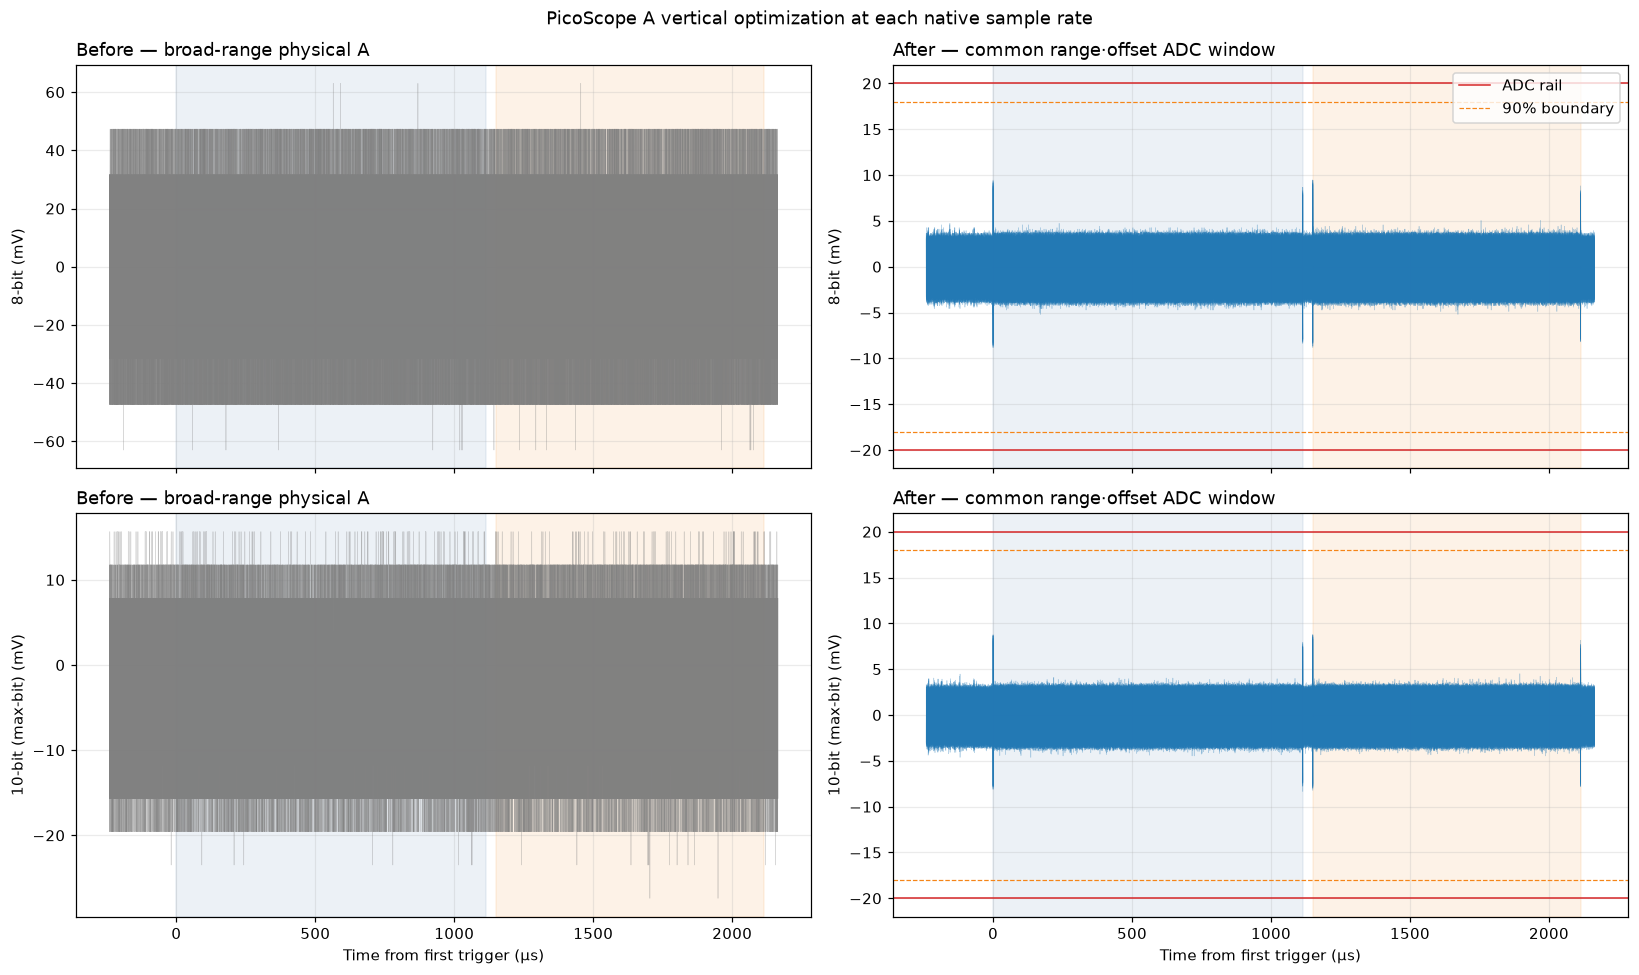

,Pico mode,device,sample rate (MS/s),interval (ns),samples/target clock,trace samples,duration (µs),retained trace (MiB),A+B transfer (MiB)
0,8-bit,Lite,7.384609,135.417,1.000,"17,800","2,410.419",0.07,nan
1,8-bit,Husky,29.538024,33.855,4.000,"71,100","2,407.067",0.27,nan
2,8-bit,PicoScope,"2,500.000000",0.400,338.547,"6,011,000","2,404.400",11.47,22.93
3,10-bit (max-bit),Lite,7.384609,135.417,1.000,"17,800","2,410.419",0.07,nan
4,10-bit (max-bit),Husky,29.538024,33.855,4.000,"71,100","2,407.067",0.27,nan
5,10-bit (max-bit),PicoScope,"1,250.000000",0.800,169.273,"3,006,000","2,404.800",5.73,11.47


,Pico mode,fixed,random,retries,max A occupancy,over-range captures,two-pulse captures
0,8-bit,5,100,0,49.6%,0,105
1,10-bit (max-bit),5,100,0,45.2%,0,105


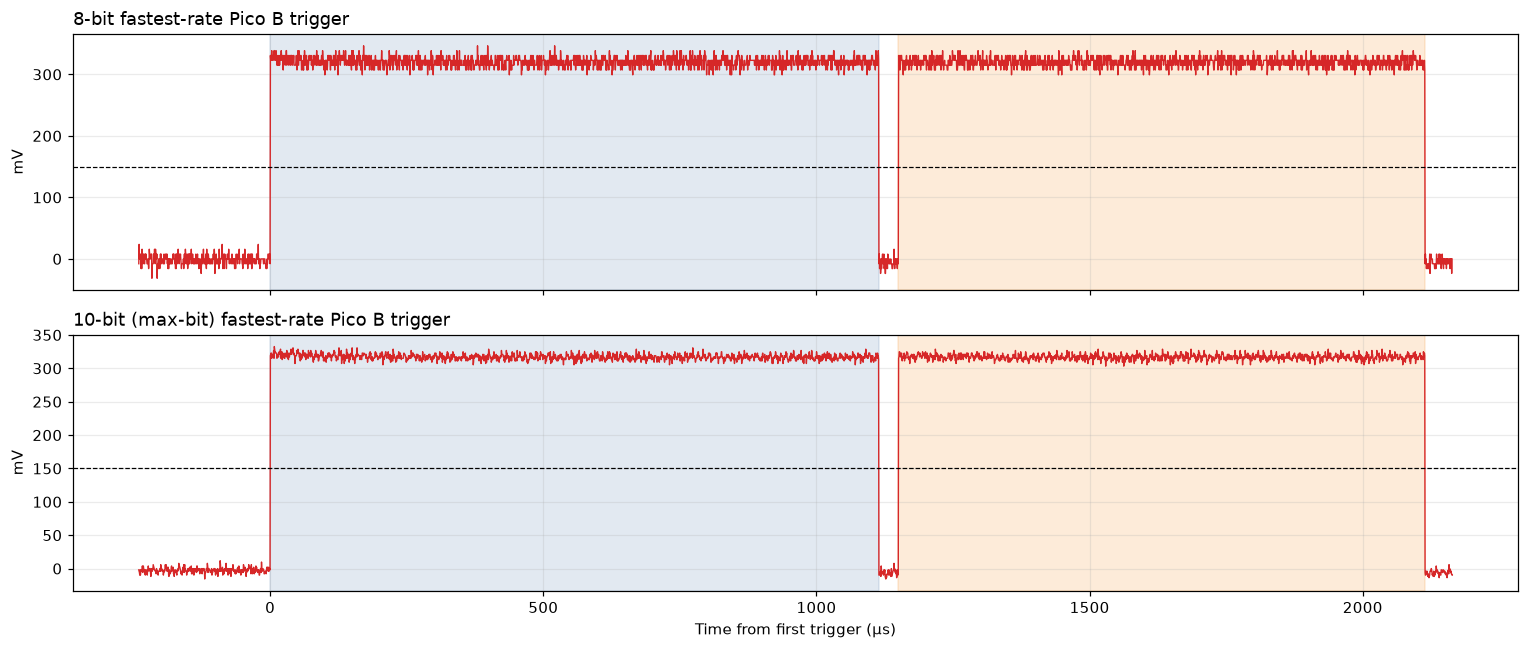

In [5]:
vertical = EXPERIMENT['pico_vertical']
preflight = EXPERIMENT['vertical_preflight']
vertical_rows = []
validation_trace_tables = []
for mode_label, case in EXPERIMENT['cases'].items():
    discovery = preflight['discovery_summaries'][mode_label]
    validation = preflight['validation_summaries'][mode_label]
    vertical_rows.append(
        {
            'Pico mode': mode_label,
            'validation rounds': preflight['validation_rounds'],
            'A coupling': 'DC 50 Ω',
            'B coupling': 'DC 1 MΩ',
            'common A range': f"±{vertical['full_scale_mv']:g} mV",
            'common A offset (mV)': vertical['offset_v'] * 1_000.0,
            'A bandwidth (MHz)': case['pico_bandwidth_hz'] / 1e6,
            'discovery physical min/max (mV)': (
                f'{discovery["global_min_mv"]:.3f} / '
                f'{discovery["global_max_mv"]:.3f}'
            ),
            'validation physical min/max (mV)': (
                f'{validation["global_min_mv"]:.3f} / '
                f'{validation["global_max_mv"]:.3f}'
            ),
            'P-P utilization': validation['utilization'],
            'effective ADC levels': validation['effective_levels'],
            'validation max rail': validation['rail_fraction'],
            'minimum headroom': validation['headroom'],
            'preflight over-range': validation['over_range_count'],
            'formal max rail': case['formal_max_rail_fraction'],
        }
    )
    trace_table = validation['per_trace'].copy()
    trace_table.insert(0, 'Pico mode', mode_label)
    validation_trace_tables.append(trace_table)

VERTICAL_STATUS = pd.DataFrame(vertical_rows)
display(
    VERTICAL_STATUS.style.format(
        {
            'common A offset (mV)': '{:+.3f}',
            'A bandwidth (MHz)': '{:,.1f}',
            'P-P utilization': '{:.1%}',
            'effective ADC levels': '{:,.1f}',
            'validation max rail': '{:.1%}',
            'minimum headroom': '{:.1%}',
            'formal max rail': '{:.1%}',
        }
    )
)
VALIDATION_TRACES = pd.concat(
    validation_trace_tables, ignore_index=True
)
display(
    VALIDATION_TRACES.style.format(
        {
            'min_mv': '{:.3f}', 'p0.1_mv': '{:.3f}',
            'p99.9_mv': '{:.3f}', 'max_mv': '{:.3f}',
            'peak_to_peak_mv': '{:.3f}',
            'rail_fraction': '{:.1%}',
        }
    )
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
for row, (mode_label, _) in enumerate(EXPERIMENT['cases'].items()):
    discovery_records = preflight['discovery'][mode_label]['records']
    validation_records = preflight['validation'][mode_label]['records']
    for record in discovery_records:
        axes[row, 0].plot(
            record['display_time_us'], record['display_physical_mv'],
            color='#7f7f7f', alpha=0.30, lw=0.45,
        )
    for record in validation_records:
        axes[row, 1].plot(
            record['display_time_us'], record['display_adc_window_mv'],
            color='#1f77b4', alpha=0.30, lw=0.45,
        )
    for sign in (-1, 1):
        axes[row, 1].axhline(
            sign * vertical['full_scale_mv'], color='#d62728', lw=1,
            label='ADC rail' if row == 0 and sign > 0 else None,
        )
        axes[row, 1].axhline(
            sign * vertical['full_scale_mv'] * PICO_VERTICAL_RAIL_LIMIT,
            color='#f58518', ls='--', lw=0.8,
            label='90% boundary' if row == 0 and sign > 0 else None,
        )
    for column in range(2):
        pulses = (discovery_records if column == 0 else validation_records)[0]['pulses_us']
        axes[row, column].axvspan(*pulses[0], color='#4c78a8', alpha=0.10)
        axes[row, column].axvspan(*pulses[1], color='#f58518', alpha=0.10)
        axes[row, column].grid(alpha=0.25)
        axes[row, column].set_ylabel(f'{mode_label} (mV)')
    axes[row, 0].set_title('Before — broad-range physical A', loc='left')
    axes[row, 1].set_title('After — common range·offset ADC window', loc='left')
axes[0, 1].legend(loc='upper right')
axes[-1, 0].set_xlabel('Time from first trigger (µs)')
axes[-1, 1].set_xlabel('Time from first trigger (µs)')
fig.suptitle('PicoScope A vertical optimization at each native sample rate')
plt.tight_layout()
plt.show()

geometry_rows = []
for mode_label, case in EXPERIMENT['cases'].items():
    for device in ('Lite', 'Husky', 'PicoScope'):
        geometry = case['geometry'][device]
        samples = int(geometry['samples'])
        bytes_per_sample = 2 if device == 'PicoScope' else 4
        geometry_rows.append(
            {
                'Pico mode': mode_label,
                'device': device,
                'sample rate (MS/s)': (
                    geometry['sample_rate_sps'] / 1e6
                ),
                'interval (ns)': (
                    geometry['sample_interval_s'] * 1e9
                ),
                'samples/target clock': (
                    geometry['sample_rate_sps']
                    / EXPERIMENT['target_clock_hz']
                ),
                'trace samples': samples,
                'duration (µs)': geometry['duration_us'],
                'retained trace (MiB)': (
                    samples * bytes_per_sample / 2**20
                ),
                'A+B transfer (MiB)': (
                    samples * 4 / 2**20
                    if device == 'PicoScope'
                    else np.nan
                ),
            }
        )
GEOMETRY_STATS = pd.DataFrame(geometry_rows)
display(
    GEOMETRY_STATS.style.format(
        {
            'sample rate (MS/s)': '{:,.6f}',
            'interval (ns)': '{:,.3f}',
            'samples/target clock': '{:,.3f}',
            'trace samples': '{:,}',
            'duration (µs)': '{:,.3f}',
            'retained trace (MiB)': '{:,.2f}',
            'A+B transfer (MiB)': '{:,.2f}',
        }
    )
)

capture_rows = []
for mode_label, case in EXPERIMENT['cases'].items():
    all_records = case['fixed'] + case['random']
    capture_rows.append(
        {
            'Pico mode': mode_label,
            'fixed': len(case['fixed']),
            'random': len(case['random']),
            'retries': sum(
                record['retry_count'] for record in all_records
            ),
            'max A occupancy': max(
                record['peak_adc_fraction']
                for record in all_records
            ),
            'over-range captures': sum(
                record['over_range_mask'] != 0
                for record in all_records
            ),
            'two-pulse captures': sum(
                len(record['pulses_us']) == 2
                for record in all_records
            ),
        }
    )
CAPTURE_STATUS = pd.DataFrame(capture_rows)
display(
    CAPTURE_STATUS.style.format(
        {'max A occupancy': '{:.1%}'}
    )
)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for axis, (mode_label, case) in zip(
    axes, EXPERIMENT['cases'].items()
):
    record = case['fixed'][0]
    geometry = case['geometry']['PicoScope']
    raw_b = record['pico_b_raw']
    step = max(1, len(raw_b) // DISPLAY_ENVELOPE_POINTS)
    indices = np.arange(0, len(raw_b), step)
    time_us = (
        geometry['start_us']
        + indices / geometry['sample_rate_sps'] * 1e6
    )
    b_mv = (
        raw_b[indices] * case['pico_b_mv_per_count']
    )
    axis.plot(time_us, b_mv, color='#d62728', lw=0.9)
    axis.axhline(
        PICO_TRIGGER_THRESHOLD_MV,
        color='black',
        ls='--',
        lw=0.8,
    )
    for pulse, color in zip(
        record['pulses_us'], ('#4c78a8', '#f58518')
    ):
        axis.axvspan(*pulse, color=color, alpha=0.16)
    axis.set_title(
        f'{mode_label} fastest-rate Pico B trigger',
        loc='left',
    )
    axis.set_ylabel('mV')
    axis.grid(alpha=0.25)
axes[-1].set_xlabel('Time from first trigger (µs)')
plt.tight_layout()
plt.show()

## 5. 서로 다른 길이의 원시 파형을 육안으로 비교

첫 번째 그림은 같은 고정 입력을 사용한 네 측정 조건의 전체 AES+SHA
파형이다. Pico 두 줄은 같은 입력이지만 별도 실행이고, 각 Pico 줄과 해당
모드의 Lite·Husky만 같은 물리 이벤트다. 각 신호는 고유 단위를 유지하고,
Pico는 analog offset을 되돌린 물리 mV로 표시한다.

수백만 점을 브라우저에 그대로 보내면 선이 겹치고 UI가 멈출 수 있으므로
전체 그림만 각 pixel 구간의 최솟값·최댓값 envelope로 그린다. 통계는
축약하지 않은 원시 배열을 사용한다. 두 번째 2 µs 확대 그림은 실제 native
sample 위치를 보여주어 시간 해상도 차이를 직접 확인하게 한다.

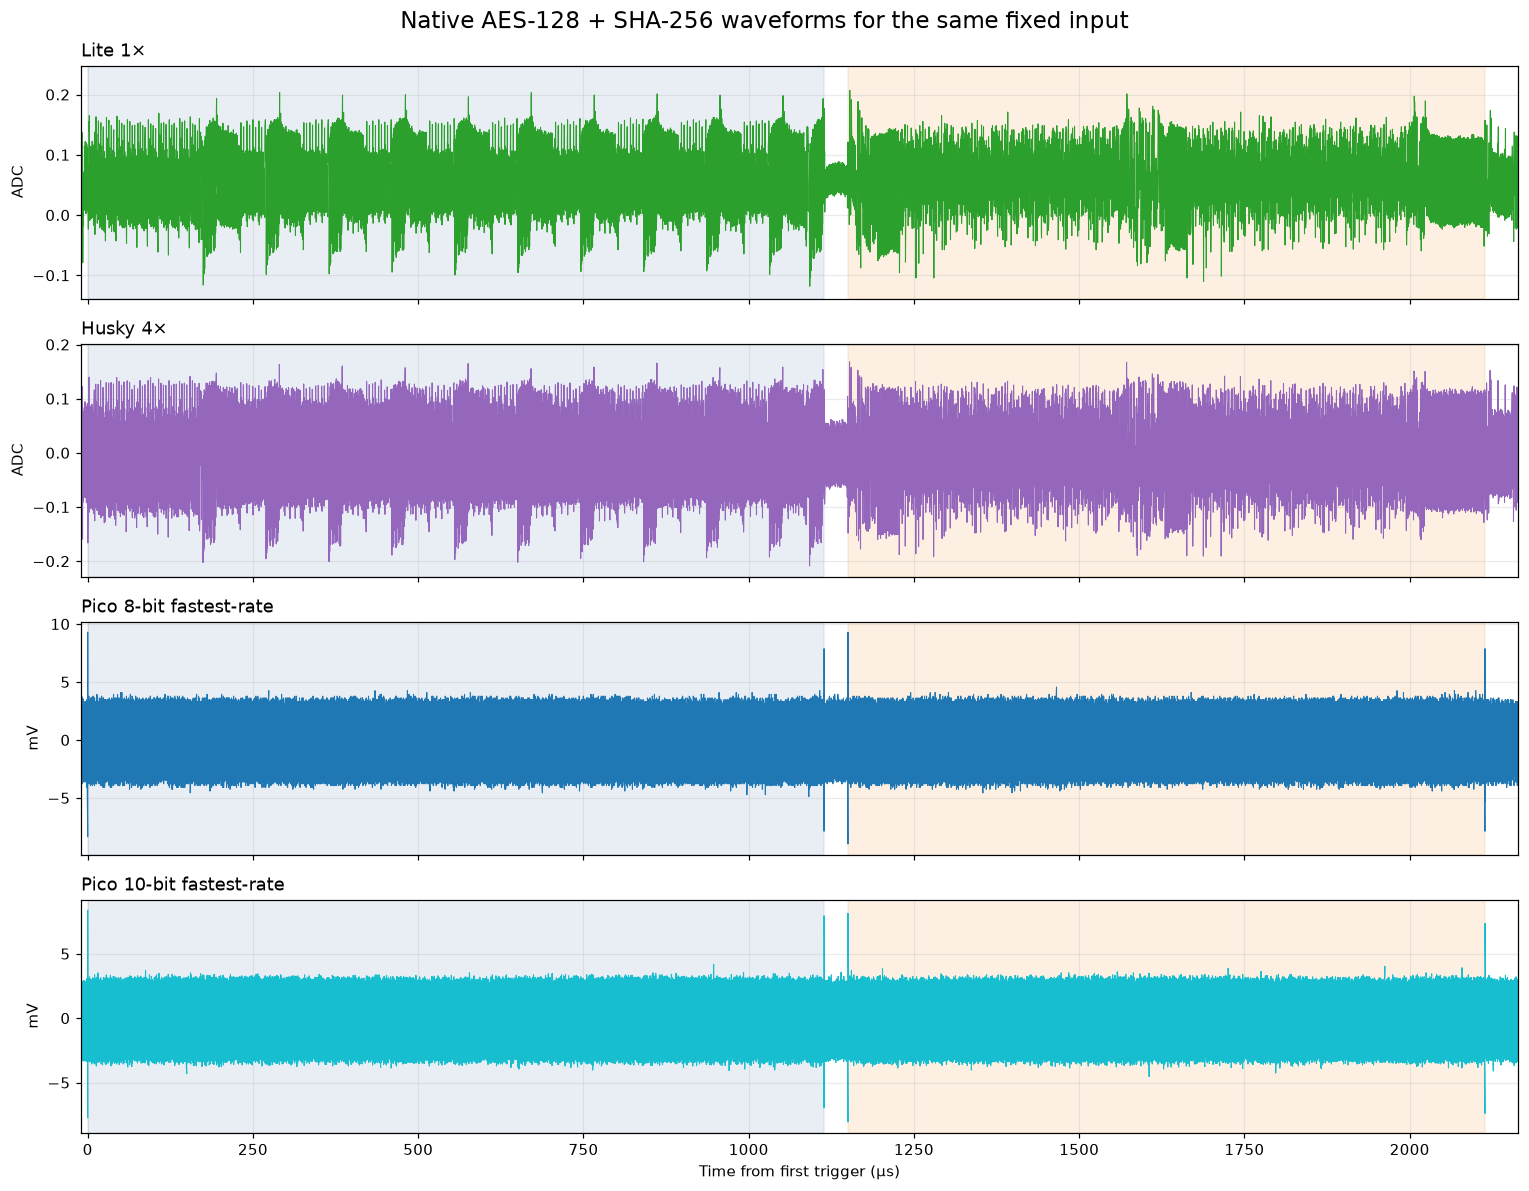

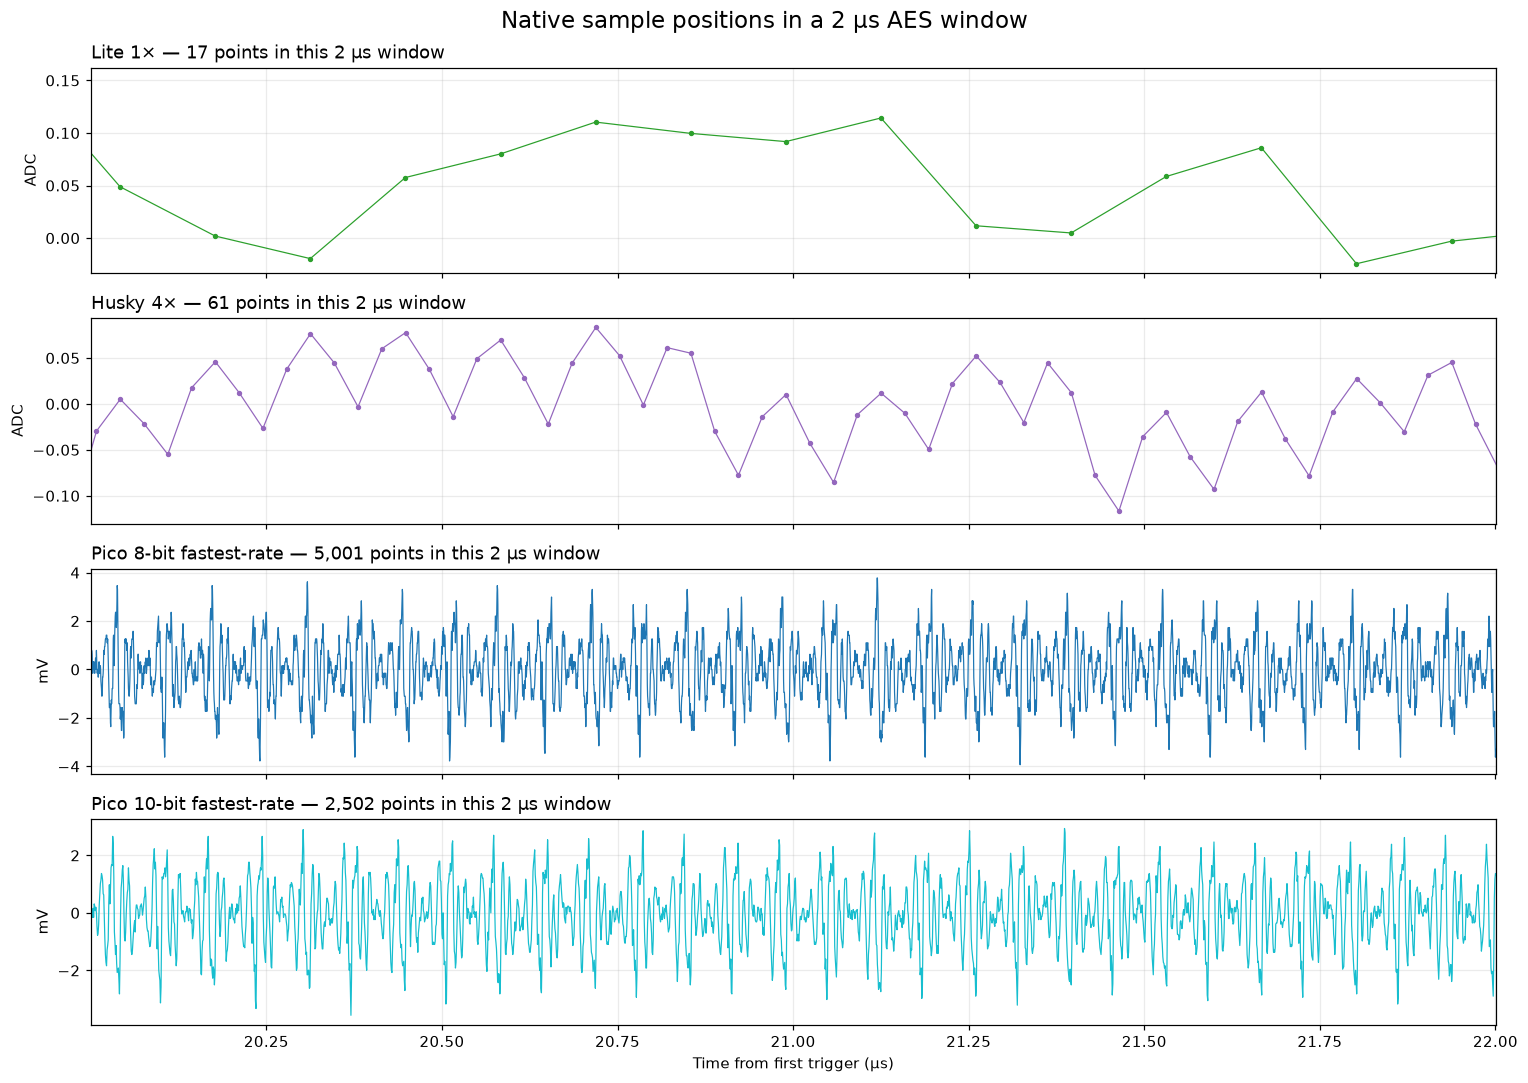

,측정 조건,2 µs sample points
0,Lite 1×,17
1,Husky 4×,61
2,Pico 8-bit fastest-rate,5001
3,Pico 10-bit fastest-rate,2502


In [6]:
representative_series = []
case_8 = EXPERIMENT['cases']['8-bit']
case_10 = EXPERIMENT['cases']['10-bit (max-bit)']
representative_series.extend(
    [
        (
            'Lite 1×',
            case_8['fixed'][0]['lite'],
            case_8['geometry']['Lite'],
            1.0,
            '#2ca02c',
            case_8['fixed'][0]['pulses_us'],
        ),
        (
            'Husky 4×',
            case_8['fixed'][0]['husky'],
            case_8['geometry']['Husky'],
            1.0,
            '#9467bd',
            case_8['fixed'][0]['pulses_us'],
        ),
        (
            'Pico 8-bit fastest-rate',
            pico_raw_to_physical_mv(
                case_8, case_8['fixed'][0]['pico_a_raw']
            ),
            case_8['geometry']['PicoScope'],
            1.0,
            '#1f77b4',
            case_8['fixed'][0]['pulses_us'],
        ),
        (
            'Pico 10-bit fastest-rate',
            pico_raw_to_physical_mv(
                case_10, case_10['fixed'][0]['pico_a_raw']
            ),
            case_10['geometry']['PicoScope'],
            1.0,
            '#17becf',
            case_10['fixed'][0]['pulses_us'],
        ),
    ]
)

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
for axis, (
    title,
    values,
    geometry,
    scale,
    color,
    pulses,
) in zip(axes, representative_series):
    time_us, display_values = minmax_display(
        np.asarray(values) * scale,
        geometry['start_us'],
        geometry['sample_rate_sps'],
        DISPLAY_ENVELOPE_POINTS,
    )
    axis.plot(time_us, display_values, color=color, lw=0.7)
    axis.axvspan(*pulses[0], color='#4c78a8', alpha=0.12)
    axis.axvspan(*pulses[1], color='#f58518', alpha=0.12)
    axis.set_title(title, loc='left')
    axis.set_ylabel('mV' if title.startswith('Pico') else 'ADC')
    axis.grid(alpha=0.25)
axes[-1].set_xlabel('Time from first trigger (µs)')
axes[-1].set_xlim(
    case_8['fixed'][0]['pulses_us'][0][0] - 10,
    case_8['fixed'][0]['pulses_us'][1][1]
    + CAPTURE_POST_MARGIN_US,
)
fig.suptitle(
    'Native AES-128 + SHA-256 waveforms for the same fixed input',
    fontsize=15,
)
plt.tight_layout()
plt.show()

zoom_start = case_8['fixed'][0]['pulses_us'][0][0] + 20.0
zoom_end = zoom_start + 2.0
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
zoom_rows = []
for axis, (
    title,
    values,
    geometry,
    scale,
    color,
    _,
) in zip(axes, representative_series):
    start_index = max(
        0,
        int(
            np.floor(
                (zoom_start - geometry['start_us'])
                * geometry['sample_rate_sps']
                / 1e6
            )
        ),
    )
    end_index = min(
        len(values),
        int(
            np.ceil(
                (zoom_end - geometry['start_us'])
                * geometry['sample_rate_sps']
                / 1e6
            )
        )
        + 1,
    )
    indices = np.arange(start_index, end_index)
    time_us = (
        geometry['start_us']
        + indices / geometry['sample_rate_sps'] * 1e6
    )
    samples = np.asarray(values)[indices] * scale
    marker = 'o' if len(indices) < 200 else None
    axis.plot(
        time_us,
        samples,
        color=color,
        lw=0.8,
        marker=marker,
        ms=2.5,
    )
    axis.set_title(
        f'{title} — {len(indices):,} points in this 2 µs window',
        loc='left',
    )
    axis.set_ylabel('mV' if title.startswith('Pico') else 'ADC')
    axis.grid(alpha=0.25)
    zoom_rows.append((title, len(indices)))
axes[-1].set_xlabel('Time from first trigger (µs)')
axes[-1].set_xlim(zoom_start, zoom_end)
fig.suptitle('Native sample positions in a 2 µs AES window', fontsize=15)
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        zoom_rows, columns=['측정 조건', '2 µs sample points']
    )
)

## 6. 공통 시간축 전처리

길이가 다른 배열의 index를 그대로 비교하면 같은 물리 시각끼리 대응하지
않는다. 먼저 각 장비의 실제 sample rate와 pre-trigger로 시간축을 만들고,
모든 장비가 공유하는 구간을 Lite 속도의 격자로 투영한다.

높은 sample rate 신호를 낮출 때 단순 선형 보간만 하면 alias가 생긴다.
따라서 실제 rate 비를 유리수로 근사한 polyphase FIR resampling을 먼저
적용하고 마지막 sub-sample 위치만 선형 보간한다. 전체 fixed/random
공통축 파형은 COMMON_TRACES에 float32로 남기며 원시 EXPERIMENT 배열은
변경하지 않는다.

In [7]:
DEVICE_FIELDS = {
    'Lite': 'lite',
    'Husky': 'husky',
    'PicoScope': 'pico_a_raw',
}
DEVICE_PAIRS = (
    ('Lite', 'Husky'),
    ('Lite', 'PicoScope'),
    ('Husky', 'PicoScope'),
)
STAGE_ORDER = ('AES-128', 'SHA-256', 'Composite')


def stage_bounds(pulses):
    '''두 trigger pulse에서 AES, SHA와 둘을 합친 구간을 반환한다.'''
    aes, sha = pulses
    return {
        'AES-128': tuple(aes),
        'SHA-256': tuple(sha),
        'Composite': (aes[0], sha[1]),
    }


def paired_stage_bounds(first_pulses, second_pulses):
    '''별도 실행 두 개의 공통 AES·SHA 시간 교집합을 반환한다.'''
    first = stage_bounds(first_pulses)
    second = stage_bounds(second_pulses)
    result = {}
    for stage in STAGE_ORDER:
        start = max(first[stage][0], second[stage][0])
        end = min(first[stage][1], second[stage][1])
        if end <= start:
            raise RuntimeError(
                f'{stage} 공통 시간 구간이 없습니다.'
            )
        result[stage] = (start, end)
    return result


def record_values(case, record, device):
    '''한 원시 record를 장비 고유 전압/ADC 단위 float32로 반환한다.'''
    values = record[DEVICE_FIELDS[device]]
    if device == 'PicoScope':
        return pico_raw_to_physical_mv(case, values)
    return np.asarray(values, dtype=np.float32)


def sample_on_grid(
    values, source_rate, source_start_us, target_grid_us
):
    '''anti-alias resampling 후 지정된 물리 시간 격자에 값을 반환한다.

    target가 source보다 빠르면 ValueError를 발생시킨다. filter 출력의
    시작 시각은 source와 같으며 입력 배열은 변경하지 않는다.
    '''
    target_rate = 1e6 / float(
        target_grid_us[1] - target_grid_us[0]
    )
    if target_rate > source_rate * (1.0 + 1e-9):
        raise ValueError(
            f'upsampling은 비교 격자로 허용하지 않습니다: '
            f'{source_rate} -> {target_rate}'
        )
    ratio = Fraction(
        float(target_rate / source_rate)
    ).limit_denominator(10_000)
    if ratio.numerator == ratio.denominator:
        filtered = np.asarray(values, dtype=np.float32)
        filtered_rate = float(source_rate)
    else:
        filtered = signal.resample_poly(
            np.asarray(values, dtype=np.float32),
            ratio.numerator,
            ratio.denominator,
            padtype='line',
        )
        filtered_rate = (
            source_rate * ratio.numerator / ratio.denominator
        )
    positions = (
        (target_grid_us - source_start_us)
        * filtered_rate
        / 1e6
    )
    if positions.min() < -1e-6 or positions.max() > len(filtered):
        raise RuntimeError('공통 격자가 source 파형 범위를 벗어납니다.')
    positions = np.clip(positions, 0, len(filtered) - 1)
    left = np.floor(positions).astype(np.int64)
    right = np.minimum(left + 1, len(filtered) - 1)
    fraction = positions - left
    output = (
        filtered[left] * (1.0 - fraction)
        + filtered[right] * fraction
    )
    return np.asarray(output, dtype=np.float32)


all_geometries = [
    case['geometry'][device]
    for case in EXPERIMENT['cases'].values()
    for device in DEVICE_FIELDS
]
common_rate_sps = min(
    case['sample_rates']['Lite']
    for case in EXPERIMENT['cases'].values()
)
common_start_us = max(
    geometry['start_us'] for geometry in all_geometries
)
common_end_us = min(
    geometry['start_us'] + geometry['duration_us']
    for geometry in all_geometries
)
common_grid_us = np.arange(
    common_start_us,
    common_end_us,
    1e6 / common_rate_sps,
)

COMMON_TRACES = {
    'grid_us': common_grid_us,
    'sample_rate_sps': common_rate_sps,
    'cases': {},
}
for mode_label, case in EXPERIMENT['cases'].items():
    COMMON_TRACES['cases'][mode_label] = {}
    for kind in ('fixed', 'random'):
        converted = {}
        for device in DEVICE_FIELDS:
            geometry = case['geometry'][device]
            rows = np.empty(
                (len(case[kind]), len(common_grid_us)),
                dtype=np.float32,
            )
            for index, record in enumerate(case[kind]):
                rows[index] = sample_on_grid(
                    record_values(case, record, device),
                    geometry['sample_rate_sps'],
                    geometry['start_us'],
                    common_grid_us,
                )
            converted[device] = rows
        COMMON_TRACES['cases'][mode_label][kind] = converted
        print(
            f'[✓] {mode_label} {kind}: '
            f'{len(case[kind])}개를 '
            f'{common_rate_sps / 1e6:.6f} MS/s 공통축으로 변환'
        )
        gc.collect()

print(
    f'[✓] 공통축 {len(common_grid_us):,} points, '
    f'{common_grid_us[0]:.3f}–{common_grid_us[-1]:.3f} µs'
)

[✓] 8-bit fixed: 5개를 7.384609 MS/s 공통축으로 변환
[✓] 8-bit random: 100개를 7.384609 MS/s 공통축으로 변환
[✓] 10-bit (max-bit) fixed: 5개를 7.384609 MS/s 공통축으로 변환
[✓] 10-bit (max-bit) random: 100개를 7.384609 MS/s 공통축으로 변환
[✓] 공통축 17,756 points, -240.440–2163.885 µs


## 7. 정량 유사성: 공통 대역과 Pico 공통 고해상도

각 구간은 DC·선형 추세를 제거하고 표준편차 1로 정규화한다. ±2 µs 안에서
절대 상호상관이 최대인 지연을 찾고 극성을 보정한다.

- abs correlation: gain·offset을 제외한 시간 파형 모양의 유사성
- polarity: 같은 극성인지 반전됐는지
- lag ns: 두 번째 파형에 대한 상대 지연
- z-NRMSE: 정렬·극성 보정된 표준화 파형의 RMS 차이
- PSD cosine: 공통 대역 주파수 에너지 분포의 cosine similarity

모든 장비 쌍은 Lite 공통축에서 비교한다. 별도 실행인 Pico 8-bit와 10-bit는
추가로 10-bit 실제 sample rate 공통축에서 비교한다. 이 고해상도 비교는
전체 sample로 correlation·z-NRMSE·PSD를 계산하지만, 계산 시간을 제한하기
위해 지연 탐색 신호만 최대 100 MS/s로 anti-alias 축소한다.

In [8]:
def bounded_power_spectrum(values, max_windows=SPECTRUM_WINDOWS):
    '''최대 16개 균등 구간의 평균 one-sided power를 반환한다.'''
    values = np.asarray(values, dtype=np.float64)
    segment_samples = min(
        SPECTRUM_SEGMENT_SAMPLES, len(values)
    )
    segment_samples -= segment_samples % 2
    if segment_samples < 8:
        raise RuntimeError('주파수 통계에 필요한 sample이 부족합니다.')
    if len(values) == segment_samples:
        starts = np.asarray([0])
    else:
        starts = np.unique(
            np.linspace(
                0,
                len(values) - segment_samples,
                min(
                    max_windows,
                    int(
                        np.ceil(
                            len(values) / segment_samples
                        )
                    ),
                ),
                dtype=int,
            )
        )
    window = np.hanning(segment_samples)
    power = np.zeros(segment_samples // 2 + 1)
    for start in starts:
        part = values[start:start + segment_samples]
        part = signal.detrend(part, type='linear') * window
        power += np.abs(np.fft.rfft(part)) ** 2
    return power / len(starts)


def standardized(values):
    '''선형 추세를 없앤 뒤 평균 0, 표준편차 1 파형을 반환한다.'''
    values = signal.detrend(
        np.asarray(values, dtype=np.float64), type='linear'
    )
    deviation = float(np.std(values))
    if not np.isfinite(deviation) or deviation == 0:
        raise RuntimeError('표준화할 수 없는 상수/비유한 파형입니다.')
    return (values - np.mean(values)) / deviation


def align_arrays(first, second, lag):
    '''lag sample만큼 두 배열을 겹쳐 같은 길이 view로 반환한다.'''
    if lag < 0:
        return first[:lag], second[-lag:]
    if lag > 0:
        return first[lag:], second[:-lag]
    return first, second


def aligned_similarity(first, second, sample_rate_sps):
    '''정렬된 상관·극성·지연·z-NRMSE·PSD cosine을 반환한다.'''
    first = np.asarray(first)
    second = np.asarray(second)
    if len(first) != len(second):
        raise ValueError('유사성 입력 두 배열 길이가 다릅니다.')

    search_rate = min(
        sample_rate_sps, PICO_ALIGNMENT_RATE_LIMIT_SPS
    )
    if search_rate < sample_rate_sps:
        ratio = Fraction(
            float(search_rate / sample_rate_sps)
        ).limit_denominator(10_000)
        search_first = signal.resample_poly(
            first, ratio.numerator, ratio.denominator
        )
        search_second = signal.resample_poly(
            second, ratio.numerator, ratio.denominator
        )
        search_rate = (
            sample_rate_sps
            * ratio.numerator
            / ratio.denominator
        )
    else:
        search_first = first
        search_second = second

    search_first = standardized(search_first)
    search_second = standardized(search_second)
    correlation = signal.correlate(
        search_first,
        search_second,
        mode='full',
        method='fft',
    )
    lags = signal.correlation_lags(
        len(search_first), len(search_second), mode='full'
    )
    maximum_lag = max(
        1,
        int(
            round(
                ALIGNMENT_LIMIT_US * search_rate / 1e6
            )
        ),
    )
    valid = np.abs(lags) <= maximum_lag
    selected = int(
        np.flatnonzero(valid)[
            np.argmax(np.abs(correlation[valid]))
        ]
    )
    lag_seconds = lags[selected] / search_rate
    lag_samples = int(round(lag_seconds * sample_rate_sps))

    aligned_first, aligned_second = align_arrays(
        first, second, lag_samples
    )
    first_z = standardized(aligned_first)
    second_z = standardized(aligned_second)
    final_correlation = float(
        np.mean(first_z * second_z)
    )
    polarity = 1.0 if final_correlation >= 0 else -1.0
    z_nrmse = float(
        np.sqrt(
            np.mean(
                (first_z - polarity * second_z) ** 2
            )
        )
    )
    first_power = bounded_power_spectrum(aligned_first)
    second_power = bounded_power_spectrum(aligned_second)
    denominator = (
        np.linalg.norm(first_power)
        * np.linalg.norm(second_power)
    )
    if denominator == 0:
        raise RuntimeError('PSD cosine 분모가 0입니다.')
    psd_cosine = float(
        np.dot(first_power, second_power) / denominator
    )
    return {
        'correlation': final_correlation,
        'abs_correlation': abs(final_correlation),
        'polarity': (
            'same' if final_correlation >= 0 else 'inverted'
        ),
        'lag_ns': lag_seconds * 1e9,
        'z_nrmse': z_nrmse,
        'psd_cosine': psd_cosine,
    }


def grid_slice(grid_us, bounds):
    '''물리 bounds 안에 든 공통 grid slice를 반환한다.'''
    start = int(np.searchsorted(grid_us, bounds[0], side='left'))
    end = int(np.searchsorted(grid_us, bounds[1], side='right'))
    if end - start < 8:
        raise RuntimeError(f'분석 구간이 너무 짧습니다: {bounds}')
    return slice(start, end)


metric_rows = []
for mode_label, case in EXPERIMENT['cases'].items():
    common_case = COMMON_TRACES['cases'][mode_label]['random']
    for trace_index, record in enumerate(case['random']):
        for stage, bounds in stage_bounds(
            record['pulses_us']
        ).items():
            region = grid_slice(common_grid_us, bounds)
            for first_device, second_device in DEVICE_PAIRS:
                metrics = aligned_similarity(
                    common_case[first_device][trace_index, region],
                    common_case[second_device][trace_index, region],
                    common_rate_sps,
                )
                metric_rows.append(
                    {
                        'Pico mode': mode_label,
                        'grid': 'Lite common',
                        'trace': trace_index,
                        'stage': stage,
                        'pair': (
                            f'{first_device} – {second_device}'
                        ),
                        **metrics,
                    }
                )

pico_pair = 'Pico 8-bit – Pico 10-bit'
common_8 = COMMON_TRACES['cases']['8-bit']['random'][
    'PicoScope'
]
common_10 = COMMON_TRACES['cases']['10-bit (max-bit)']['random'][
    'PicoScope'
]
for trace_index, (record_8, record_10) in enumerate(
    zip(case_8['random'], case_10['random'])
):
    bounds_by_stage = paired_stage_bounds(
        record_8['pulses_us'], record_10['pulses_us']
    )
    for stage, bounds in bounds_by_stage.items():
        region = grid_slice(common_grid_us, bounds)
        metrics = aligned_similarity(
            common_8[trace_index, region],
            common_10[trace_index, region],
            common_rate_sps,
        )
        metric_rows.append(
            {
                'Pico mode': '8-bit vs 10-bit',
                'grid': 'Lite common',
                'trace': trace_index,
                'stage': stage,
                'pair': pico_pair,
                **metrics,
            }
        )

pico_common_rate = min(
    case_8['sample_rates']['PicoScope'],
    case_10['sample_rates']['PicoScope'],
)
pico_common_start = max(
    case_8['geometry']['PicoScope']['start_us'],
    case_10['geometry']['PicoScope']['start_us'],
)
pico_common_end = min(
    case_8['geometry']['PicoScope']['start_us']
    + case_8['geometry']['PicoScope']['duration_us'],
    case_10['geometry']['PicoScope']['start_us']
    + case_10['geometry']['PicoScope']['duration_us'],
)
pico_common_grid_us = np.arange(
    pico_common_start,
    pico_common_end,
    1e6 / pico_common_rate,
)
pico_representative = None
for trace_index, (record_8, record_10) in enumerate(
    zip(case_8['random'], case_10['random'])
):
    high_8 = sample_on_grid(
        record_values(case_8, record_8, 'PicoScope'),
        case_8['sample_rates']['PicoScope'],
        case_8['geometry']['PicoScope']['start_us'],
        pico_common_grid_us,
    )
    high_10 = sample_on_grid(
        record_values(case_10, record_10, 'PicoScope'),
        case_10['sample_rates']['PicoScope'],
        case_10['geometry']['PicoScope']['start_us'],
        pico_common_grid_us,
    )
    if trace_index == 0:
        pico_representative = {
            'grid_us': pico_common_grid_us,
            '8-bit': high_8.copy(),
            '10-bit (max-bit)': high_10.copy(),
        }
    bounds_by_stage = paired_stage_bounds(
        record_8['pulses_us'], record_10['pulses_us']
    )
    for stage, bounds in bounds_by_stage.items():
        region = grid_slice(pico_common_grid_us, bounds)
        metrics = aligned_similarity(
            high_8[region],
            high_10[region],
            pico_common_rate,
        )
        metric_rows.append(
            {
                'Pico mode': '8-bit vs 10-bit',
                'grid': 'Pico 10-bit common',
                'trace': trace_index,
                'stage': stage,
                'pair': pico_pair,
                **metrics,
            }
        )
    if (trace_index + 1) % 10 == 0:
        print(
            '[Pico direct] '
            f'{trace_index + 1}/{RANDOM_CAPTURES}'
        )
    del high_8, high_10
    gc.collect()

COMMON_TRACES['pico_pair_representative'] = pico_representative
METRICS = pd.DataFrame(metric_rows)

metric_summary = (
    METRICS.groupby(
        ['Pico mode', 'grid', 'stage', 'pair'], sort=False
    )
    .agg(
        abs_corr_median=('abs_correlation', 'median'),
        abs_corr_iqr=(
            'abs_correlation',
            lambda values: (
                values.quantile(0.75) - values.quantile(0.25)
            ),
        ),
        lag_median_ns=('lag_ns', 'median'),
        lag_iqr_ns=(
            'lag_ns',
            lambda values: (
                values.quantile(0.75) - values.quantile(0.25)
            ),
        ),
        z_nrmse_median=('z_nrmse', 'median'),
        psd_cosine_median=('psd_cosine', 'median'),
        inverted_count=(
            'polarity',
            lambda values: int((values == 'inverted').sum()),
        ),
    )
    .reset_index()
)
display(metric_summary.round(5))

[Pico direct] 10/100
[Pico direct] 20/100
[Pico direct] 30/100
[Pico direct] 40/100
[Pico direct] 50/100
[Pico direct] 60/100
[Pico direct] 70/100
[Pico direct] 80/100
[Pico direct] 90/100
[Pico direct] 100/100


,Pico mode,grid,stage,pair,abs_corr_median,abs_corr_iqr,lag_median_ns,lag_iqr_ns,z_nrmse_median,psd_cosine_median,inverted_count
0,8-bit,Lite common,AES-128,Lite – Husky,0.89519,0.00044,270.83357,0.0,0.45784,0.99179,0
1,8-bit,Lite common,AES-128,Lite – PicoScope,0.50690,0.00656,677.08392,0.0,0.99308,0.67994,0
2,8-bit,Lite common,AES-128,Husky – PicoScope,0.50748,0.00737,406.25035,0.0,0.99250,0.72061,0
3,8-bit,Lite common,SHA-256,Lite – Husky,0.94319,0.00044,270.83357,0.0,0.33709,0.98693,0
4,8-bit,Lite common,SHA-256,Lite – PicoScope,0.55708,0.00597,677.08392,0.0,0.94119,0.50860,0
5,8-bit,Lite common,SHA-256,Husky – PicoScope,0.50048,0.00526,0.00000,0.0,0.99952,0.53145,100
6,8-bit,Lite common,Composite,Lite – Husky,0.91539,0.00030,270.83357,0.0,0.41137,0.98705,0
7,8-bit,Lite common,Composite,Lite – PicoScope,0.52770,0.00391,677.08392,0.0,0.97191,0.63381,0
8,8-bit,Lite common,Composite,Husky – PicoScope,0.48811,0.00533,406.25035,0.0,1.01182,0.66898,0
9,10-bit (max-bit),Lite common,AES-128,Lite – Husky,0.89517,0.00040,270.83357,0.0,0.45788,0.99176,0


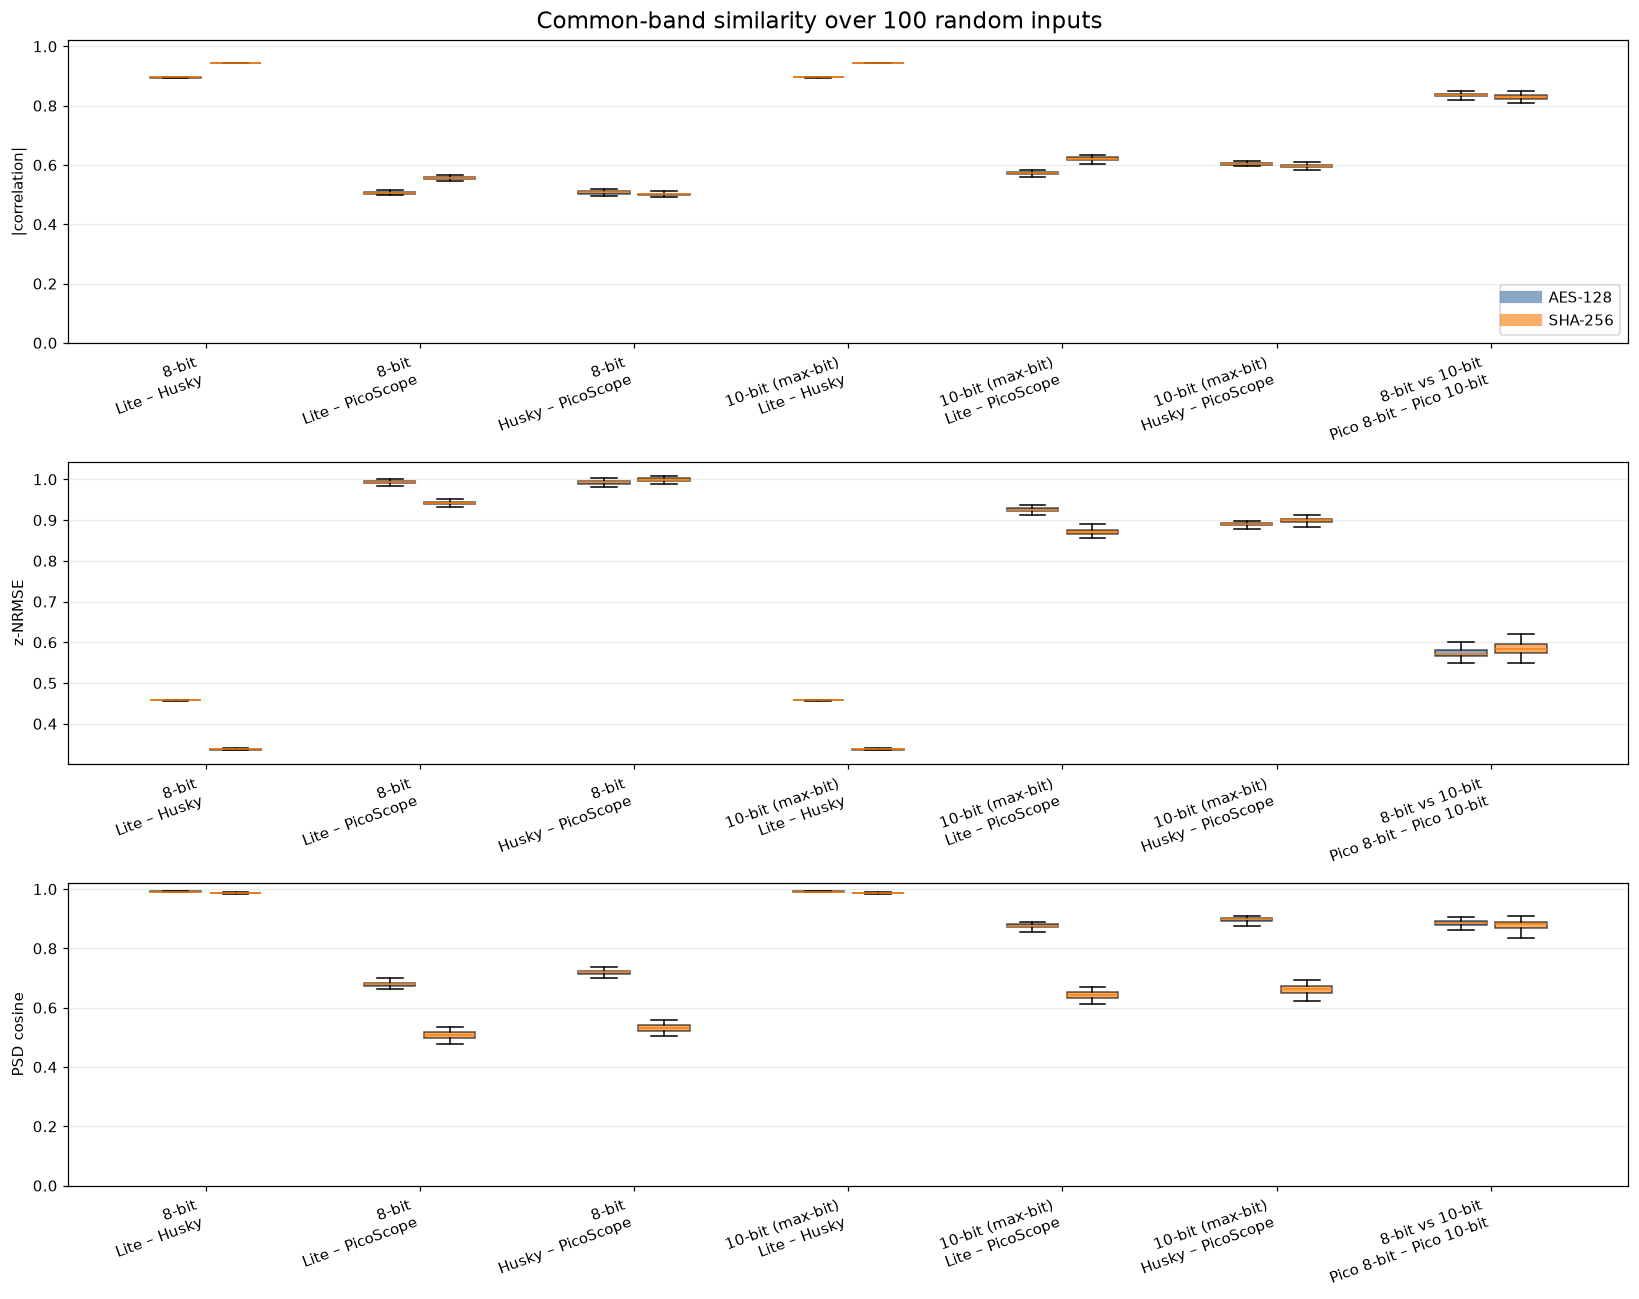

,Pico mode,grid,stage,pair,abs_corr_median,abs_corr_iqr,lag_median_ns,lag_iqr_ns,z_nrmse_median,psd_cosine_median,inverted_count
18,8-bit vs 10-bit,Lite common,AES-128,Pico 8-bit – Pico 10-bit,0.83631,0.00880,0.0,0.0,0.57217,0.88513,0
19,8-bit vs 10-bit,Lite common,SHA-256,Pico 8-bit – Pico 10-bit,0.82966,0.01254,0.0,0.0,0.58369,0.88185,0
20,8-bit vs 10-bit,Lite common,Composite,Pico 8-bit – Pico 10-bit,0.82811,0.00961,0.0,0.0,0.58632,0.86864,0
21,8-bit vs 10-bit,Pico 10-bit common,AES-128,Pico 8-bit – Pico 10-bit,0.42629,0.10425,0.0,1890.0,1.07118,0.99434,0
22,8-bit vs 10-bit,Pico 10-bit common,SHA-256,Pico 8-bit – Pico 10-bit,0.47292,0.08525,0.0,1490.0,1.02672,0.99359,0
23,8-bit vs 10-bit,Pico 10-bit common,Composite,Pico 8-bit – Pico 10-bit,0.44175,0.07385,0.0,1480.0,1.05665,0.99256,0


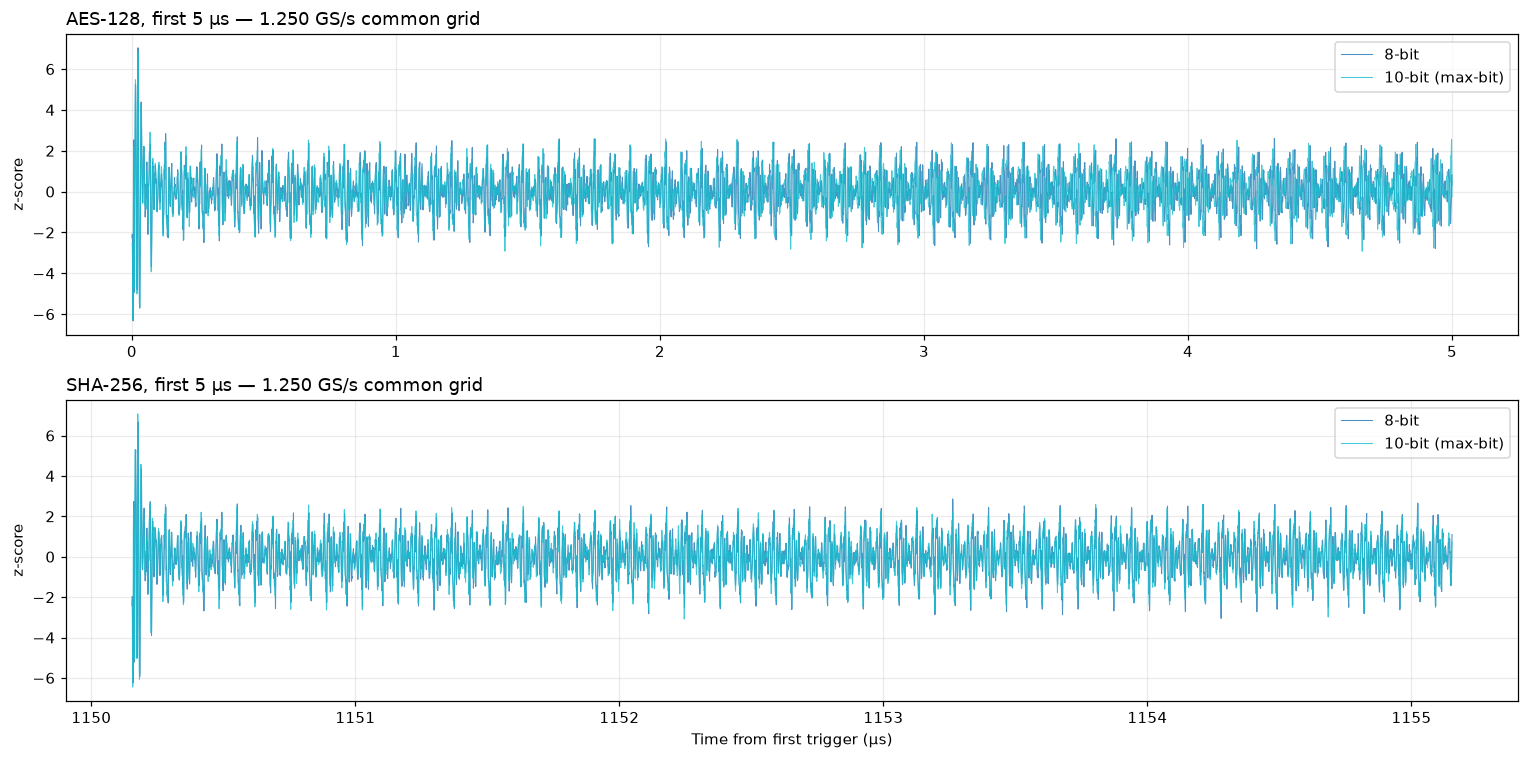

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
plotted = METRICS[
    (METRICS['grid'] == 'Lite common')
    & (METRICS['stage'].isin(['AES-128', 'SHA-256']))
].copy()
groups = list(
    plotted.groupby(['Pico mode', 'pair'], sort=False)
)
positions = np.arange(len(groups))
for axis, column, ylabel, limits in (
    (axes[0], 'abs_correlation', '|correlation|', (0, 1.02)),
    (axes[1], 'z_nrmse', 'z-NRMSE', None),
    (axes[2], 'psd_cosine', 'PSD cosine', (0, 1.02)),
):
    for stage_index, (stage, color) in enumerate(
        (('AES-128', '#4c78a8'), ('SHA-256', '#f58518'))
    ):
        values = [
            frame[frame['stage'] == stage][column].to_numpy()
            for _, frame in groups
        ]
        boxes = axis.boxplot(
            values,
            positions=positions + (stage_index - 0.5) * 0.28,
            widths=0.24,
            patch_artist=True,
            showfliers=False,
        )
        for box in boxes['boxes']:
            box.set_facecolor(color)
            box.set_alpha(0.65)
    axis.set_ylabel(ylabel)
    axis.set_xticks(positions)
    axis.set_xticklabels(
        [
            f'{key[0]}\n{key[1]}'
            for key, _ in groups
        ],
        rotation=20,
        ha='right',
    )
    axis.grid(axis='y', alpha=0.25)
    if limits:
        axis.set_ylim(*limits)
axes[0].legend(
    [
        plt.Line2D(
            [0], [0], color=color, lw=8, alpha=0.65
        )
        for color in ('#4c78a8', '#f58518')
    ],
    ['AES-128', 'SHA-256'],
    loc='lower right',
)
fig.suptitle(
    'Common-band similarity over 100 random inputs',
    fontsize=15,
)
plt.tight_layout()
plt.show()

direct_summary = metric_summary[
    metric_summary['Pico mode'] == '8-bit vs 10-bit'
]
display(direct_summary.round(5))

representative = COMMON_TRACES['pico_pair_representative']
first_8 = case_8['random'][0]
first_10 = case_10['random'][0]
direct_bounds = paired_stage_bounds(
    first_8['pulses_us'], first_10['pulses_us']
)
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for axis, stage in zip(axes, ('AES-128', 'SHA-256')):
    bounds = direct_bounds[stage]
    start = bounds[0]
    end = min(bounds[1], start + 5.0)
    region = grid_slice(
        representative['grid_us'], (start, end)
    )
    for label, color in (
        ('8-bit', '#1f77b4'),
        ('10-bit (max-bit)', '#17becf'),
    ):
        values = representative[label][region]
        normalized = standardized(values)
        axis.plot(
            representative['grid_us'][region],
            normalized,
            color=color,
            lw=0.7,
            alpha=0.8,
            label=label,
        )
    axis.set_title(
        f'{stage}, first 5 µs — '
        f'{pico_common_rate / 1e9:.3f} GS/s common grid',
        loc='left',
    )
    axis.set_ylabel('z-score')
    axis.grid(alpha=0.25)
    axis.legend()
axes[-1].set_xlabel('Time from first trigger (µs)')
plt.tight_layout()
plt.show()

## 8. native 대역 에너지와 고정 입력 반복성

공통축 비교는 모든 장비가 볼 수 있는 대역만 공정하게 비교하지만, 높은
sample rate가 추가로 기록한 세부 정보를 나타내지 못한다. 따라서 원시
파형을 detrend한 뒤 Lite Nyquist와 Husky Nyquist를 경계로 에너지 비율을
계산한다. 긴 Pico 파형은 전체 시간에 균등하게 놓은 최대 16개 FFT 구간을
평균하여 특정 한 순간에 치우치지 않으면서 계산량을 제한한다.

고정 입력 5회는 입력 의존 변화가 없으므로 평균 파형에 대한 residual RMS와
반복성 SNR을 측정한다. Pico 두 모드는 같은 range·offset을 사용하므로 물리 mV
residual을 직접 비교할 수 있다. 5회뿐이므로 추론 통계가 아닌 기술 통계로
해석한다.

[native PSD] 8-bit 20/100
[native PSD] 8-bit 40/100
[native PSD] 8-bit 60/100
[native PSD] 8-bit 80/100
[native PSD] 8-bit 100/100
[native PSD] 10-bit (max-bit) 20/100
[native PSD] 10-bit (max-bit) 40/100
[native PSD] 10-bit (max-bit) 60/100
[native PSD] 10-bit (max-bit) 80/100
[native PSD] 10-bit (max-bit) 100/100


,Pico mode,stage,device,band,median,iqr
0,8-bit,AES-128,Lite,shared ≤ Lite Nyquist,100.000%,0.000%
1,8-bit,AES-128,Husky,shared ≤ Lite Nyquist,61.878%,0.450%
2,8-bit,AES-128,Husky,Lite–Husky extension,38.122%,0.450%
3,8-bit,AES-128,PicoScope,shared ≤ Lite Nyquist,0.078%,0.003%
4,8-bit,AES-128,PicoScope,Lite–Husky extension,1.067%,0.020%
5,8-bit,AES-128,PicoScope,Husky–native extension,98.854%,0.021%
6,8-bit,SHA-256,Lite,shared ≤ Lite Nyquist,100.000%,0.000%
7,8-bit,SHA-256,Husky,shared ≤ Lite Nyquist,61.348%,0.463%
8,8-bit,SHA-256,Husky,Lite–Husky extension,38.652%,0.463%
9,8-bit,SHA-256,PicoScope,shared ≤ Lite Nyquist,0.064%,0.002%


,Pico mode,stage,device,unit,residual_rms,repeatability_snr_db,correlation_median,correlation_min
0,8-bit,AES-128,Lite,normalized ADC,0.001808,28.328710,0.999271,0.999203
1,8-bit,AES-128,Husky,normalized ADC,0.003800,21.073730,0.996177,0.994842
2,8-bit,AES-128,PicoScope,mV,0.010758,9.453408,0.958942,0.956969
3,8-bit,SHA-256,Lite,normalized ADC,0.001829,27.748848,0.999186,0.998979
4,8-bit,SHA-256,Husky,normalized ADC,0.003744,20.508732,0.996169,0.993448
5,8-bit,SHA-256,PicoScope,mV,0.011845,7.766048,0.950857,0.948495
6,8-bit,Composite,Lite,normalized ADC,0.001815,28.018528,0.999232,0.999165
7,8-bit,Composite,Husky,normalized ADC,0.003772,20.758156,0.996119,0.994158
8,8-bit,Composite,PicoScope,mV,0.011278,8.605219,0.953191,0.951440
9,10-bit (max-bit),AES-128,Lite,normalized ADC,0.001875,28.032267,0.999223,0.999173


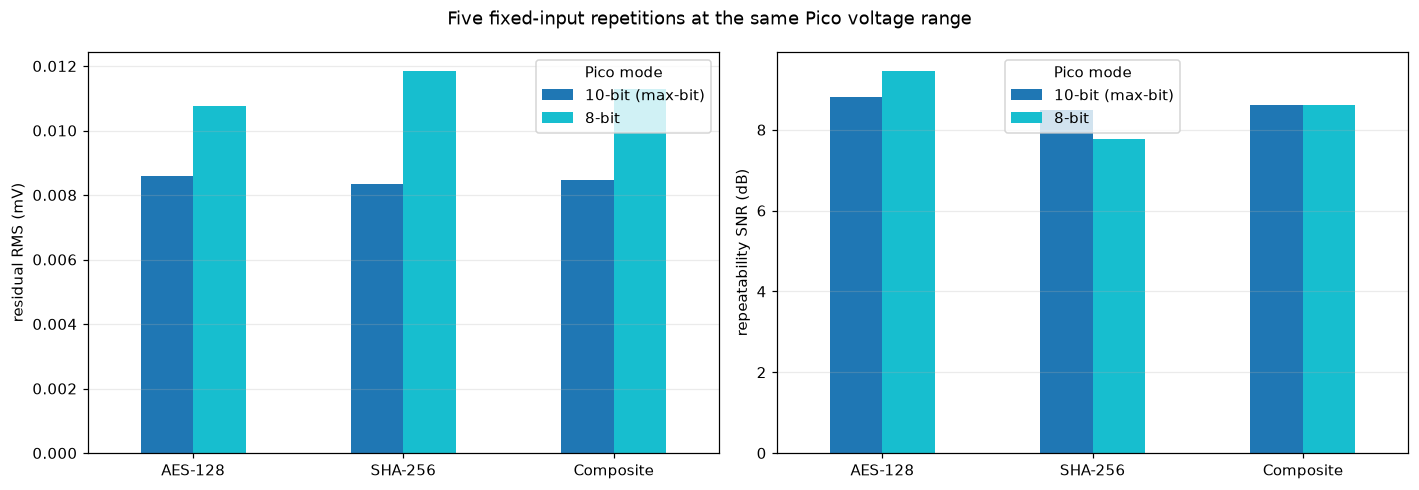

In [10]:
def native_region(case, record, device, bounds):
    '''원시 파형에서 물리 bounds에 대응하는 view와 rate를 반환한다.'''
    geometry = case['geometry'][device]
    start = max(
        0,
        int(
            np.floor(
                (bounds[0] - geometry['start_us'])
                * geometry['sample_rate_sps']
                / 1e6
            )
        ),
    )
    end = min(
        geometry['samples'],
        int(
            np.ceil(
                (bounds[1] - geometry['start_us'])
                * geometry['sample_rate_sps']
                / 1e6
            )
        ),
    )
    if end - start < 8:
        raise RuntimeError(
            f'{device} native 분석 구간이 너무 짧습니다.'
        )
    return (
        record_values(case, record, device)[start:end],
        geometry['sample_rate_sps'],
    )


lite_nyquist = min(
    case['sample_rates']['Lite']
    for case in EXPERIMENT['cases'].values()
) / 2.0
husky_nyquist = min(
    case['sample_rates']['Husky']
    for case in EXPERIMENT['cases'].values()
) / 2.0
energy_rows = []
for mode_label, case in EXPERIMENT['cases'].items():
    for trace_index, record in enumerate(case['random']):
        bounds_by_stage = stage_bounds(record['pulses_us'])
        for stage in ('AES-128', 'SHA-256'):
            for device in DEVICE_FIELDS:
                values, sample_rate = native_region(
                    case,
                    record,
                    device,
                    bounds_by_stage[stage],
                )
                power = bounded_power_spectrum(values)
                frequencies = np.fft.rfftfreq(
                    (len(power) - 1) * 2,
                    d=1.0 / sample_rate,
                )
                total = float(np.sum(power[1:]))
                if total <= 0:
                    raise RuntimeError(
                        'native spectrum energy가 0입니다.'
                    )
                for band, low, high in (
                    ('shared ≤ Lite Nyquist', 0.0, lite_nyquist),
                    (
                        'Lite–Husky extension',
                        lite_nyquist,
                        husky_nyquist,
                    ),
                    (
                        'Husky–native extension',
                        husky_nyquist,
                        sample_rate / 2.0,
                    ),
                ):
                    mask = (
                        (frequencies > max(low, 0.0))
                        & (frequencies <= min(high, sample_rate / 2.0))
                    )
                    fraction = (
                        float(np.sum(power[mask])) / total
                        if np.any(mask)
                        else np.nan
                    )
                    energy_rows.append(
                        {
                            'Pico mode': mode_label,
                            'trace': trace_index,
                            'stage': stage,
                            'device': device,
                            'band': band,
                            'energy_fraction': fraction,
                        }
                    )
        if (trace_index + 1) % 20 == 0:
            print(
                f'[native PSD] {mode_label} '
                f'{trace_index + 1}/{RANDOM_CAPTURES}'
            )

BAND_ENERGY = pd.DataFrame(energy_rows)
energy_summary = (
    BAND_ENERGY.dropna()
    .groupby(
        ['Pico mode', 'stage', 'device', 'band'],
        sort=False,
    )
    .agg(
        median=('energy_fraction', 'median'),
        iqr=(
            'energy_fraction',
            lambda values: (
                values.quantile(0.75) - values.quantile(0.25)
            ),
        ),
    )
    .reset_index()
)
display(energy_summary.style.format({'median': '{:.3%}', 'iqr': '{:.3%}'}))

repeatability_rows = []
for mode_label, case in EXPERIMENT['cases'].items():
    fixed_records = case['fixed']
    common_fixed = COMMON_TRACES['cases'][mode_label]['fixed']
    for stage in STAGE_ORDER:
        bounds_sets = [
            stage_bounds(record['pulses_us'])[stage]
            for record in fixed_records
        ]
        bounds = (
            max(item[0] for item in bounds_sets),
            min(item[1] for item in bounds_sets),
        )
        region = grid_slice(common_grid_us, bounds)
        for device in DEVICE_FIELDS:
            traces = np.asarray(
                common_fixed[device][:, region],
                dtype=np.float64,
            )
            mean_trace = np.mean(traces, axis=0)
            residuals = traces - mean_trace
            signal_rms = float(
                np.sqrt(
                    np.mean(
                        (
                            mean_trace - np.mean(mean_trace)
                        ) ** 2
                    )
                )
            )
            residual_rms = float(
                np.sqrt(np.mean(residuals ** 2))
            )
            snr_db = (
                20.0 * np.log10(signal_rms / residual_rms)
                if residual_rms > 0
                else np.inf
            )
            correlations = [
                abs(
                    float(
                        np.corrcoef(
                            trace, mean_trace
                        )[0, 1]
                    )
                )
                for trace in traces
            ]
            repeatability_rows.append(
                {
                    'Pico mode': mode_label,
                    'stage': stage,
                    'device': device,
                    'unit': (
                        'mV'
                        if device == 'PicoScope'
                        else 'normalized ADC'
                    ),
                    'residual_rms': residual_rms,
                    'repeatability_snr_db': snr_db,
                    'correlation_median': float(
                        np.median(correlations)
                    ),
                    'correlation_min': float(
                        np.min(correlations)
                    ),
                }
            )

REPEATABILITY = pd.DataFrame(repeatability_rows)
display(REPEATABILITY.round(6))

pico_repeatability = REPEATABILITY[
    REPEATABILITY['device'] == 'PicoScope'
]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for axis, column, ylabel in (
    (axes[0], 'residual_rms', 'residual RMS (mV)'),
    (axes[1], 'repeatability_snr_db', 'repeatability SNR (dB)'),
):
    pivot = pico_repeatability.pivot(
        index='stage', columns='Pico mode', values=column
    ).reindex(STAGE_ORDER)
    pivot.plot.bar(ax=axis, color=['#1f77b4', '#17becf'])
    axis.set_ylabel(ylabel)
    axis.set_xlabel('')
    axis.grid(axis='y', alpha=0.25)
    axis.tick_params(axis='x', rotation=0)
fig.suptitle(
    'Five fixed-input repetitions at the same Pico voltage range'
)
plt.tight_layout()
plt.show()

RESOLUTION_STATS = {
    'geometry': GEOMETRY_STATS,
    'band_energy': BAND_ENERGY,
    'repeatability': REPEATABILITY,
}

In [11]:
expected_per_mode = FIXED_CAPTURES + RANDOM_CAPTURES
for mode_label, case in EXPERIMENT['cases'].items():
    preflight = EXPERIMENT['vertical_preflight']
    if len(preflight['discovery'][mode_label]['records']) != PICO_VERTICAL_PREFLIGHTS:
        raise RuntimeError(f'{mode_label} 수직축 탐색 수집 수가 다릅니다.')
    if len(preflight['validation'][mode_label]['records']) != PICO_VERTICAL_PREFLIGHTS:
        raise RuntimeError(f'{mode_label} 수직축 검증 수집 수가 다릅니다.')
    vertical_summary = preflight['validation_summaries'][mode_label]
    if (
        vertical_summary['over_range_count'] != 0
        or vertical_summary['rail_fraction'] > PICO_VERTICAL_RAIL_LIMIT
    ):
        raise RuntimeError(f'{mode_label} 수직축 사전 검증 실패')
    if case['formal_max_rail_fraction'] > PICO_FORMAL_RAIL_LIMIT:
        raise RuntimeError(f'{mode_label} formal rail 한계 초과')
    if len(case['fixed']) != FIXED_CAPTURES:
        raise RuntimeError(
            f'{mode_label} fixed 수집 수가 목표와 다릅니다.'
        )
    if len(case['random']) != RANDOM_CAPTURES:
        raise RuntimeError(
            f'{mode_label} random 수집 수가 목표와 다릅니다.'
        )
    for kind in ('fixed', 'random'):
        for record in case[kind]:
            if len(record['pulses_us']) != 2:
                raise RuntimeError(
                    f'{mode_label} trigger 두 펄스 검증 실패'
                )
            if record['over_range_mask'] != 0:
                raise RuntimeError(
                    f'{mode_label} over-range record 발견'
                )

expected_metrics = (
    2 * RANDOM_CAPTURES * len(STAGE_ORDER) * len(DEVICE_PAIRS)
    + 2 * RANDOM_CAPTURES * len(STAGE_ORDER)
)
if len(METRICS) != expected_metrics:
    raise RuntimeError(
        f'METRICS {len(METRICS):,}행 != {expected_metrics:,}행'
    )
numeric_metrics = METRICS[
    [
        'correlation',
        'abs_correlation',
        'lag_ns',
        'z_nrmse',
        'psd_cosine',
    ]
].to_numpy()
if not np.isfinite(numeric_metrics).all():
    raise RuntimeError('METRICS에 NaN/Inf가 있습니다.')
if not np.isfinite(
    REPEATABILITY[
        [
            'residual_rms',
            'repeatability_snr_db',
            'correlation_median',
            'correlation_min',
        ]
    ].to_numpy()
).all():
    raise RuntimeError('반복성 통계에 NaN/Inf가 있습니다.')

total_captures = sum(
    len(case['fixed']) + len(case['random'])
    for case in EXPERIMENT['cases'].values()
)
retained_pico_bytes = sum(
    record['pico_a_raw'].nbytes
    for case in EXPERIMENT['cases'].values()
    for kind in ('fixed', 'random')
    for record in case[kind]
)

print('=== Run All 최종 결과 ===')
print(
    f'[✓] 공식 3중 수집: {total_captures}/'
    f'{expected_per_mode * len(PICO_MODES)}'
)
for mode_label, case in EXPERIMENT['cases'].items():
    geometry = case['geometry']['PicoScope']
    print(
        f'[✓] {mode_label}: '
        f'{geometry["sample_rate_sps"] / 1e9:.6f} GS/s, '
        f'{geometry["sample_interval_s"] * 1e9:.3f} ns, '
        f'{geometry["samples"]:,} points/trace'
    )
print(
    f'[✓] RAM에 보존된 Pico A 원시 데이터: '
    f'{retained_pico_bytes / 2**30:.3f} GiB'
)
vertical = EXPERIMENT['pico_vertical']
print(
    f'[✓] Pico A DC 50 Ω, B DC 1 MΩ, 공통 A '
    f'±{vertical["full_scale_mv"]:g} mV / '
    f'offset {vertical["offset_v"]:+.6f} V'
)
print(
    f'[✓] 두 Pico mode에서 수직축 탐색 10회·최종 검증 10회 통과 '
    f'(range 검증 {EXPERIMENT["vertical_preflight"]["validation_rounds"]} rounds)'
)
print('[✓] Lite 1×·Husky 4× gain 25 dB와 모든 AES·SHA 골든 결과 확인')
print('[✓] 모든 formal capture에서 Pico B 두 펄스·rail 95% 이하 확인')
print(f'[✓] 정량 유사성 {len(METRICS):,}행 생성')
print('[✓] 장비 handle과 펌웨어 build 산출물 정리 완료')
print(
    '\n표와 그래프는 계측 경로 차이를 보여주는 기술 통계이며 '
    '합격/불합격 판정이 아닙니다.'
)

=== Run All 최종 결과 ===
[✓] 공식 3중 수집: 210/210
[✓] 8-bit: 2.500000 GS/s, 0.400 ns, 6,011,000 points/trace
[✓] 10-bit (max-bit): 1.250000 GS/s, 0.800 ns, 3,006,000 points/trace
[✓] RAM에 보존된 Pico A 원시 데이터: 1.764 GiB
[✓] Pico A DC 50 Ω, B DC 1 MΩ, 공통 A ±20 mV / offset -0.000000 V
[✓] 두 Pico mode에서 수직축 탐색 10회·최종 검증 10회 통과 (range 검증 2 rounds)
[✓] Lite 1×·Husky 4× gain 25 dB와 모든 AES·SHA 골든 결과 확인
[✓] 모든 formal capture에서 Pico B 두 펄스·rail 95% 이하 확인
[✓] 정량 유사성 2,400행 생성
[✓] 장비 handle과 펌웨어 build 산출물 정리 완료

표와 그래프는 계측 경로 차이를 보여주는 기술 통계이며 합격/불합격 판정이 아닙니다.


## 해석 지침

- 수직축 검증 표에서 두 모드 모두 over-range 0, rail 점유율 90% 이하인지
  먼저 확인하고 before/after 그림에서 analog offset과 여유를 육안 확인한다.
- native 전체 및 2 µs 확대 그림에서 네 조건의 특징점 순서, ringing,
  noise floor와 실제 점 밀도를 먼저 비교한다.
- Lite 공통축의 abs correlation과 PSD cosine이 함께 높고 z-NRMSE가
  낮으면 공통 대역에서 파형 모양이 비슷하다.
- lag의 중앙값보다 IQR이 크면 아날로그 파형보다 trigger·clock 안정성을
  먼저 점검한다.
- Pico 10-bit 공통축 비교는 8-bit의 두 배 sample rate를 anti-alias
  축소한 뒤 수행하므로 배열 길이 차이 자체가 결과를 왜곡하지 않는다.
- native 대역 에너지는 높은 sample rate가 추가로 기록한 성분을,
  고정 입력 residual과 SNR은 bit depth에 따른 반복 잡음 차이를 보여준다.
- 두 Pico 모드는 동일한 입력을 사용하지만 동시 사건이 아니다. 따라서
  직접 비교 결과에는 시간에 따른 장비·환경 drift도 포함될 수 있다.

이 노트북은 최대 시간 해상도에서의 계측 유사성까지만 다룬다. Dataset
저장이나 CPA/DPA 성공률은 별도의 실험 목표와 판정 기준이 필요하다.